# 📊 Dataset Features Description

This dataset contains information about hotel bookings and customer reservations.
The features describe the booking details, customer characteristics, reservation history, and stay information.

The main objective of this project is to **predict whether a hotel booking will be canceled or not** using the available booking and customer-related features.

---

## 🗂️ Data Columns

|  # | Column                           | Description                                                                                                                   |
| -: | -------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- |
|  1 | `hotel`                          | Type of hotel where the booking was made (Resort Hotel or City Hotel).                                                        |
|  2 | `is_canceled`                    | **Target variable.** Indicates whether the booking was canceled (1) or not canceled (0).                                      |
|  3 | `lead_time`                      | Number of days between the booking date and the arrival date.                                                                 |
|  4 | `arrival_date_year`              | Year in which the guest is scheduled to arrive.                                                                               |
|  5 | `arrival_date_month`             | Month in which the guest is scheduled to arrive.                                                                              |
|  6 | `arrival_date_week_number`       | Week number of the year in which the guest is scheduled to arrive.                                                            |
|  7 | `arrival_date_day_of_month`      | Day of the month on which the guest is scheduled to arrive.                                                                   |
|  8 | `stays_in_weekend_nights`        | Number of weekend nights (Saturday or Sunday) the guest is expected to stay.                                                  |
|  9 | `stays_in_week_nights`           | Number of week nights (Monday to Friday) the guest is expected to stay.                                                       |
| 10 | `adults`                         | Number of adults included in the booking.                                                                                     |
| 11 | `children`                       | Number of children included in the booking.                                                                                   |
| 12 | `babies`                         | Number of babies included in the booking.                                                                                     |
| 13 | `meal`                           | Type of meal booked by the guest.                                                                                             |
| 14 | `country`                        | Country of origin of the guest.                                                                                               |
| 15 | `market_segment`                 | Market segment through which the booking was made, such as Online Travel Agents, Offline Travel Agents, Direct, or Corporate. |
| 16 | `distribution_channel`           | Distribution channel used to make the booking.                                                                                |
| 17 | `is_repeated_guest`              | Indicates whether the guest has stayed at the hotel before (1 = Yes, 0 = No).                                                 |
| 18 | `previous_cancellations`         | Number of previous bookings that were canceled by the guest.                                                                  |
| 19 | `previous_bookings_not_canceled` | Number of previous bookings that were not canceled by the guest.                                                              |
| 20 | `reserved_room_type`             | Room type originally reserved by the guest.                                                                                   |
| 21 | `assigned_room_type`             | Room type actually assigned to the guest.                                                                                     |
| 22 | `booking_changes`                | Number of changes made to the booking after the original reservation was created.                                             |
| 23 | `deposit_type`                   | Type of deposit required for the booking, such as No Deposit, Non Refund, or Refundable.                                      |
| 24 | `agent`                          | ID of the travel agency or booking agent responsible for the reservation.                                                     |
| 25 | `company`                        | ID of the company responsible for the booking, if applicable.                                                                 |
| 26 | `days_in_waiting_list`           | Number of days the booking remained on the waiting list before being confirmed.                                               |
| 27 | `customer_type`                  | Type of customer, such as Transient, Contract, Group, or Transient-Party.                                                     |
| 28 | `adr`                            | Average Daily Rate, representing the average price paid per occupied room per day.                                            |
| 29 | `required_car_parking_spaces`    | Number of car parking spaces requested by the guest.                                                                          |
| 30 | `total_of_special_requests`      | Total number of special requests made by the guest.                                                                           |
| 31 | `reservation_status`             | Final status of the reservation, such as Canceled, Check-Out, or No-Show.                                                     |
| 32 | `reservation_status_date`        | Date on which the final reservation status was last updated.                                                                  |

---

## 🎯 Target Variable

The target variable for this classification problem is:

`is_canceled`

* **0 → Booking was not canceled**
* **1 → Booking was canceled**

The goal is to build a Machine Learning classification model that can predict the probability of a booking cancellation based on information available about the reservation.

---

## ⚠️ Potential Data Leakage

The following columns should **not be used as input features** when predicting `is_canceled`:

* `reservation_status`
* `reservation_status_date`

These features describe the **final outcome or status of the reservation**, which becomes known after the booking process. Including them could cause **data leakage** and lead to unrealistically high model performance.

Therefore, they will be removed before model training.

---

## 📌 Dataset Summary

| Category                   | Details                                         |
| -------------------------- | ----------------------------------------------- |
| **Problem Type**           | Binary Classification                           |
| **Target Variable**        | `is_canceled`                                   |
| **Domain**                 | Hotel / Hospitality                             |
| **Main Objective**         | Predict booking cancellations                   |
| **Data Types**             | Numerical + Categorical                         |
| **Missing Values**         | Present                                         |
| **Class Imbalance**        | Present                                         |
| **Potential Data Leakage** | `reservation_status`, `reservation_status_date` |


### Libraries Used

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier 
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , OrdinalEncoder
from category_encoders import BinaryEncoder
from sklearn.preprocessing import StandardScaler , RobustScaler , MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix , accuracy_score  , precision_score , recall_score , f1_score , roc_auc_score , roc_curve
from sklearn.model_selection import cross_val_score , GridSearchCV , RandomizedSearchCV
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_validate


### Read DataSet

In [3]:
df = pd.read_csv('hotel_bookings.csv')

### Data Exploration

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [6]:
df.sample()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
18029,Resort Hotel,0,79,2015,October,44,29,0,2,2,...,No Deposit,240.0,NaN,0,Transient,40.5,0,1,Check-Out,2015-10-31


In [7]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [8]:
df.shape

(119390, 32)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [10]:
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [11]:
missing_values = df.isna().sum() / len(df) * 100
missing_values.sort_values(ascending=False)

company                           94.306893
agent                             13.686238
country                            0.408744
children                           0.003350
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
hotel                              0.000000
is_canceled                        0.000000
stays_in_weekend_nights            0.000000
arrival_date_day_of_month          0.000000
adults                             0.000000
stays_in_week_nights               0.000000
babies                             0.000000
meal                               0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
distribution_channel               0.000000
market_segment                     0.000000
previous_bookings_not_canceled     0.000000
is_repeated_guest                  0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                 

In [12]:
df.describe().round()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119386.0,119390.0,119390.0,119390.0,119390.0,119390.0,103050.0,6797.0,119390.0,119390.0,119390.0,119390.0
mean,0.0,104.0,2016.0,27.0,16.0,1.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,87.0,189.0,2.0,102.0,0.0,1.0
std,0.0,107.0,1.0,14.0,9.0,1.0,2.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,111.0,132.0,18.0,51.0,0.0,1.0
min,0.0,0.0,2015.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,0.0,-6.0,0.0,0.0
25%,0.0,18.0,2016.0,16.0,8.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,62.0,0.0,69.0,0.0,0.0
50%,0.0,69.0,2016.0,28.0,16.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,179.0,0.0,95.0,0.0,0.0
75%,1.0,160.0,2017.0,38.0,23.0,2.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,229.0,270.0,0.0,126.0,0.0,1.0
max,1.0,737.0,2017.0,53.0,31.0,19.0,50.0,55.0,10.0,10.0,1.0,26.0,72.0,21.0,535.0,543.0,391.0,5400.0,8.0,5.0


In [13]:
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


In [14]:
df.duplicated().sum()

np.int64(31994)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.loc[df['adr'] < 0, 'adr'] = np.nan

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
numeric_columns


['is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'company',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [19]:
categorical_columns = [
    col for col in df.select_dtypes(include='object').columns
    if col not in ['country', 'reservation_status_date']
]
categorical_columns

['hotel',
 'arrival_date_month',
 'meal',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status']

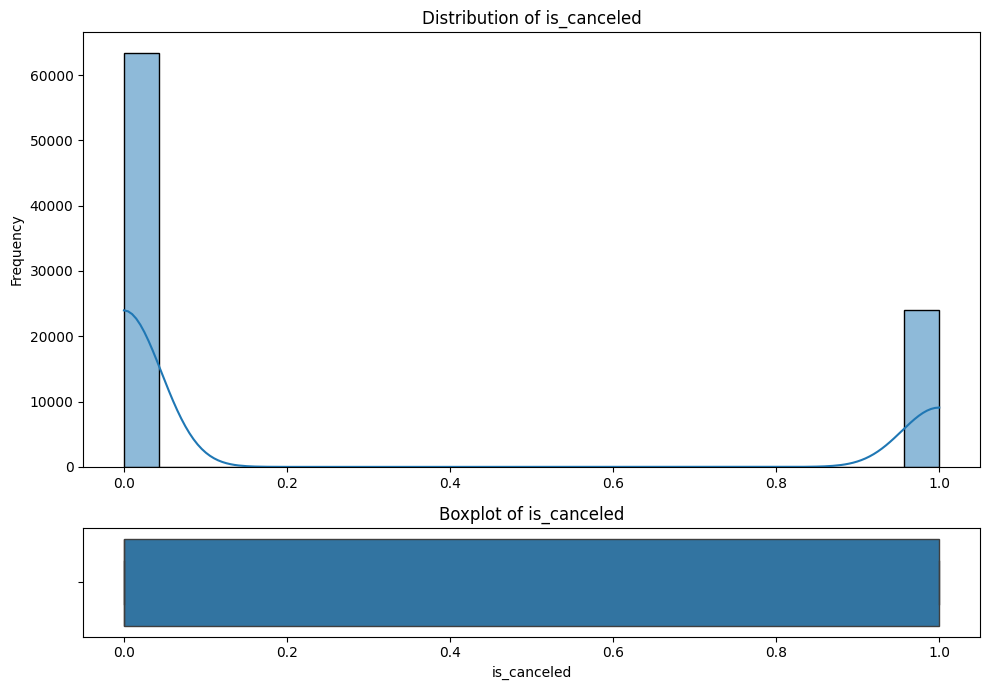

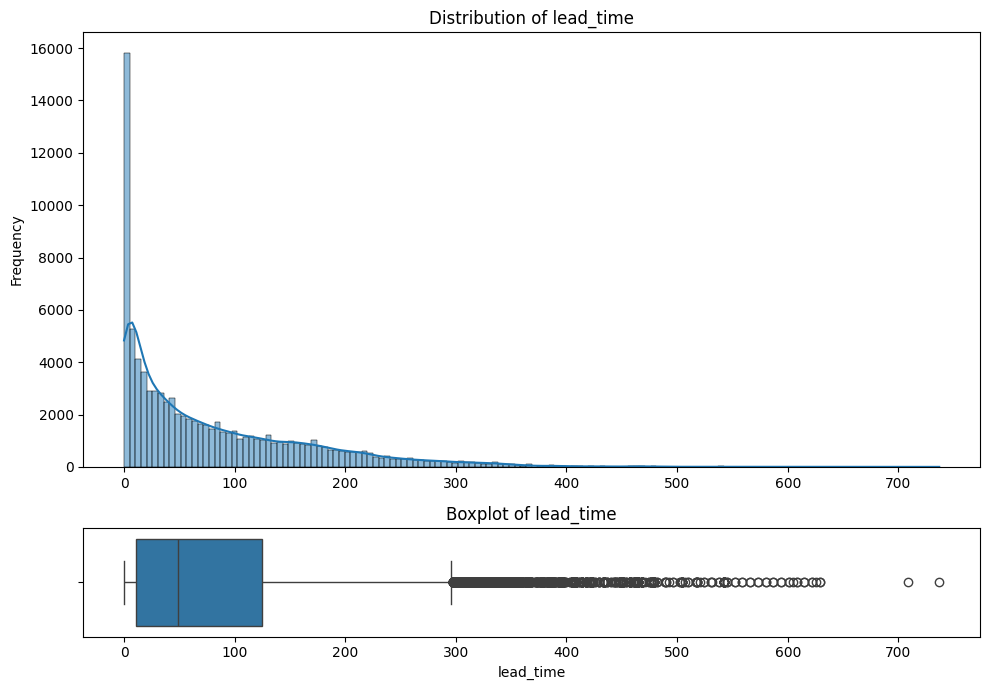

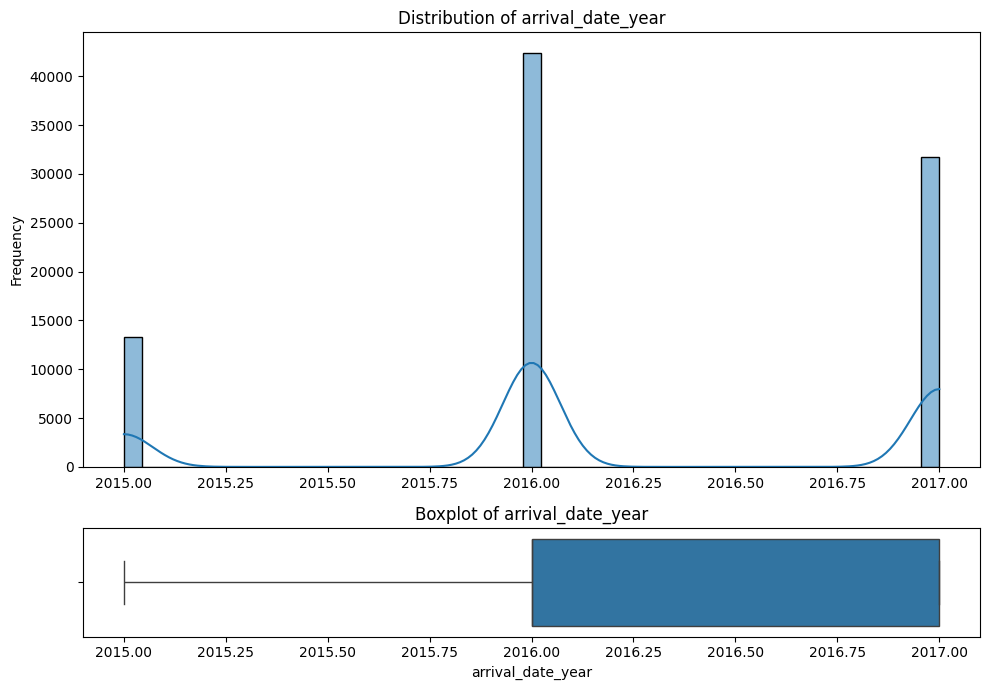

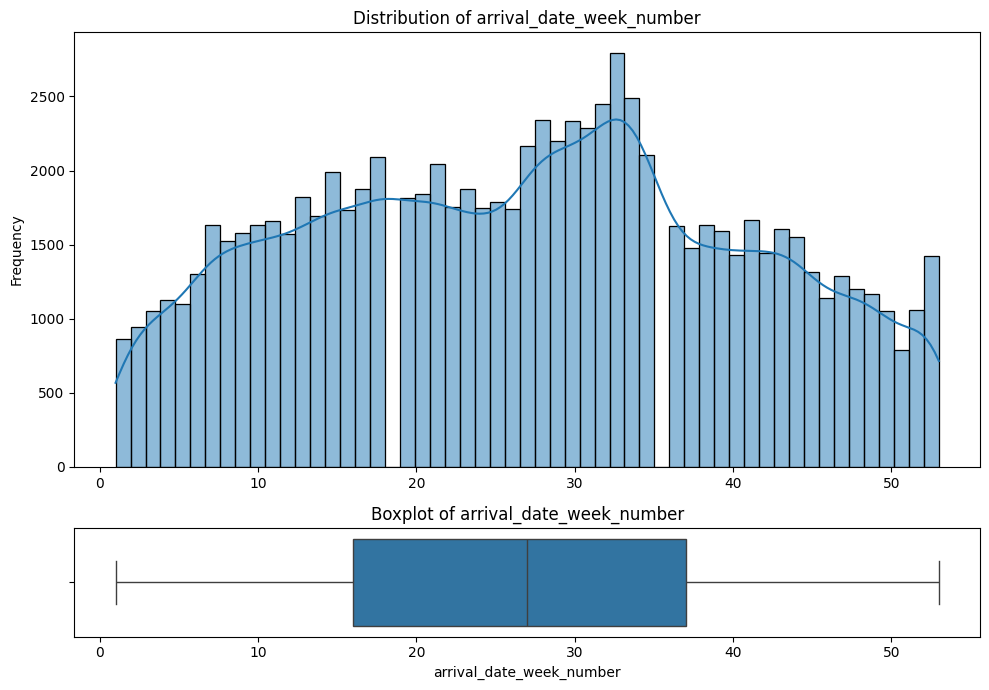

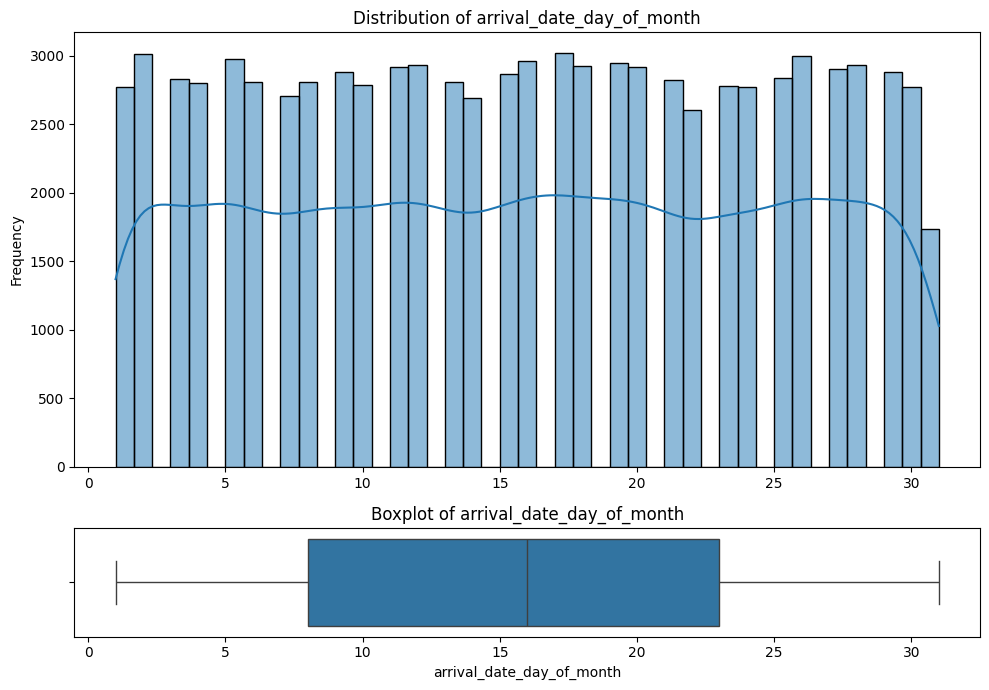

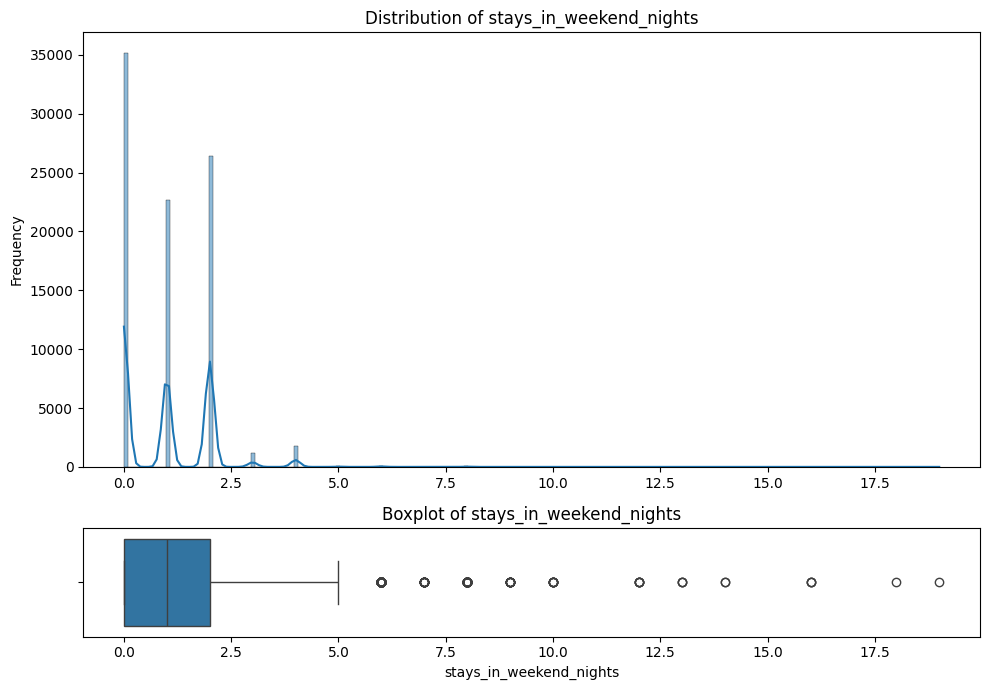

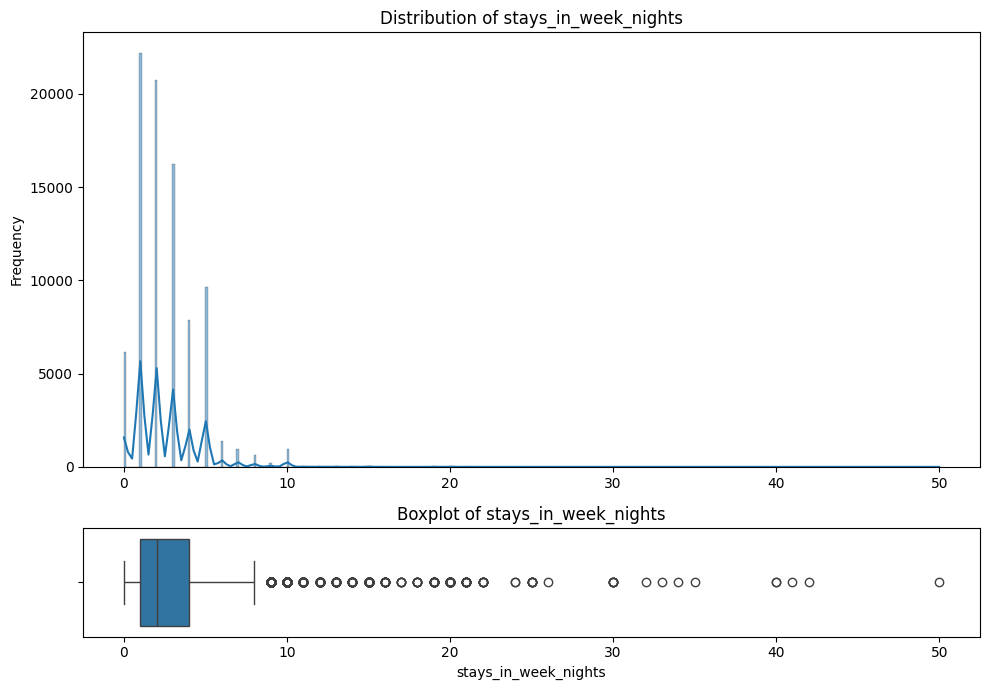

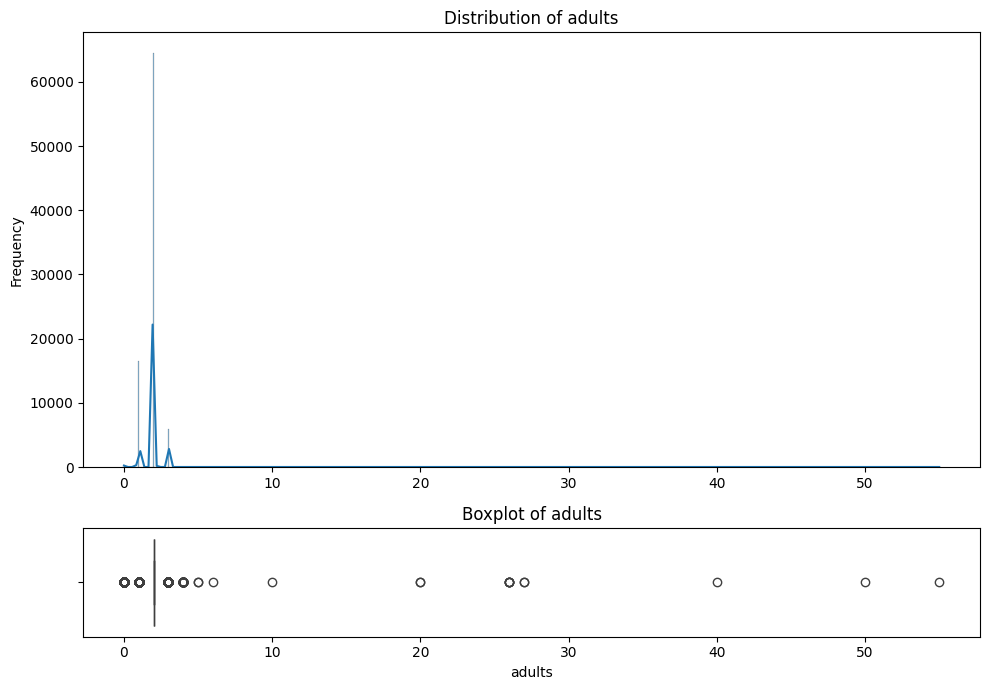

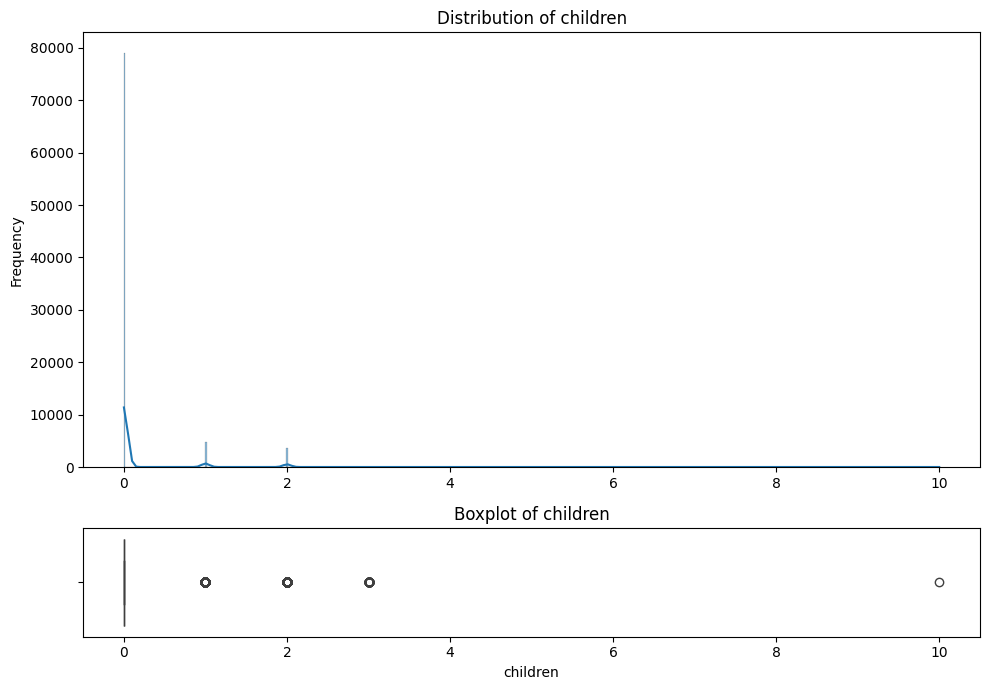

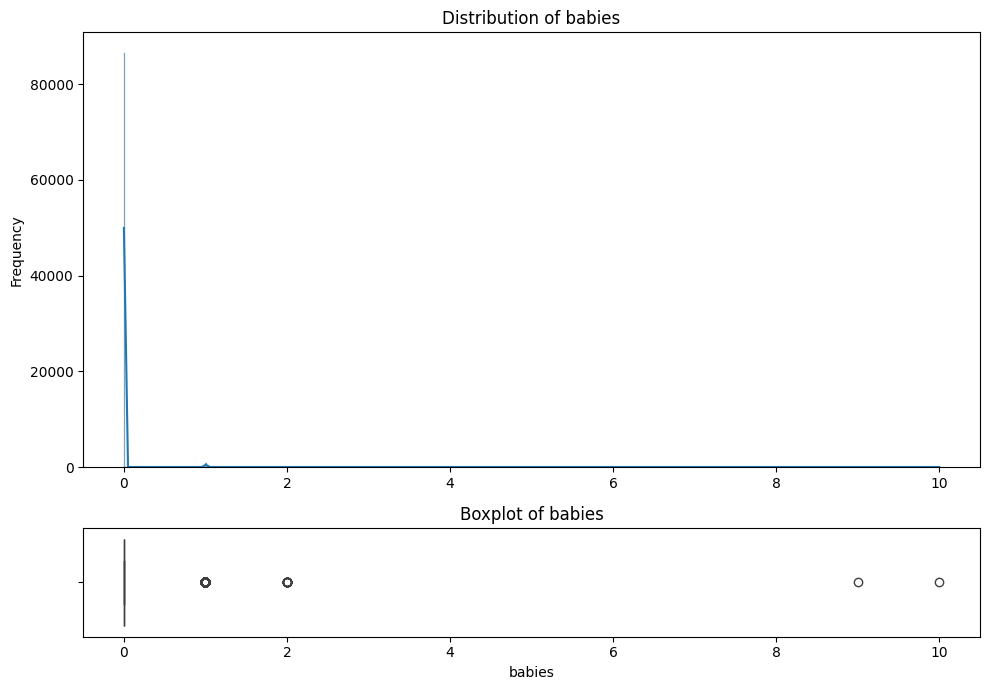

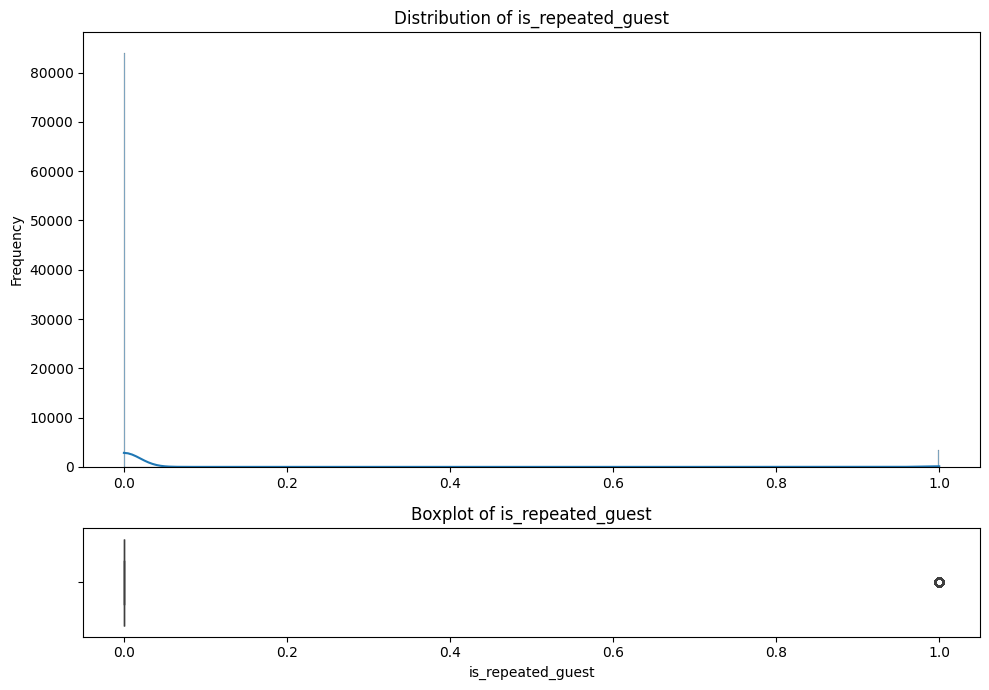

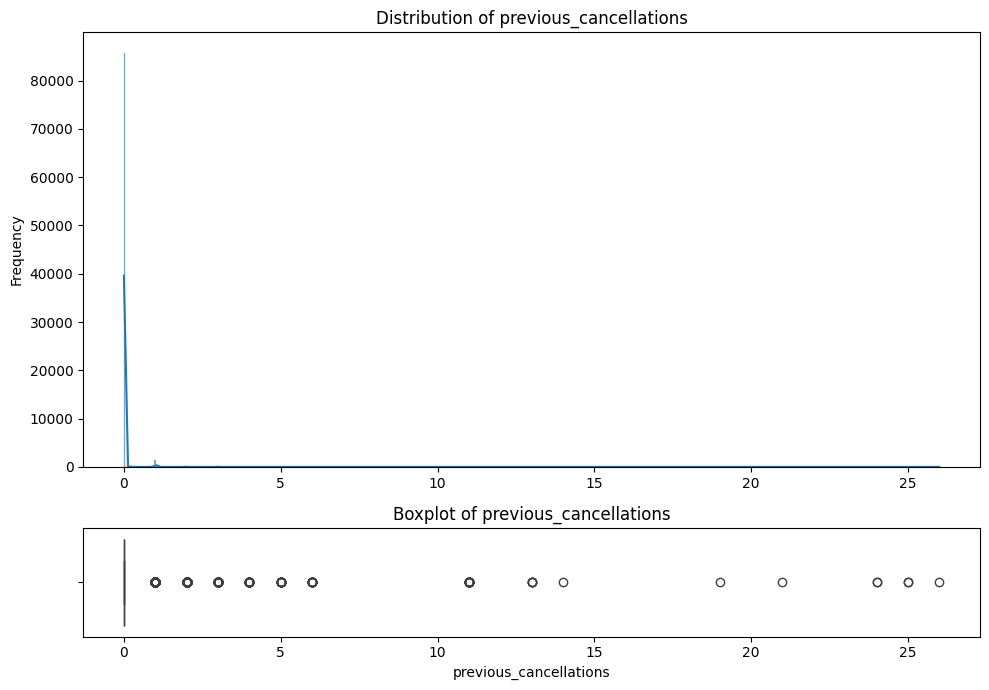

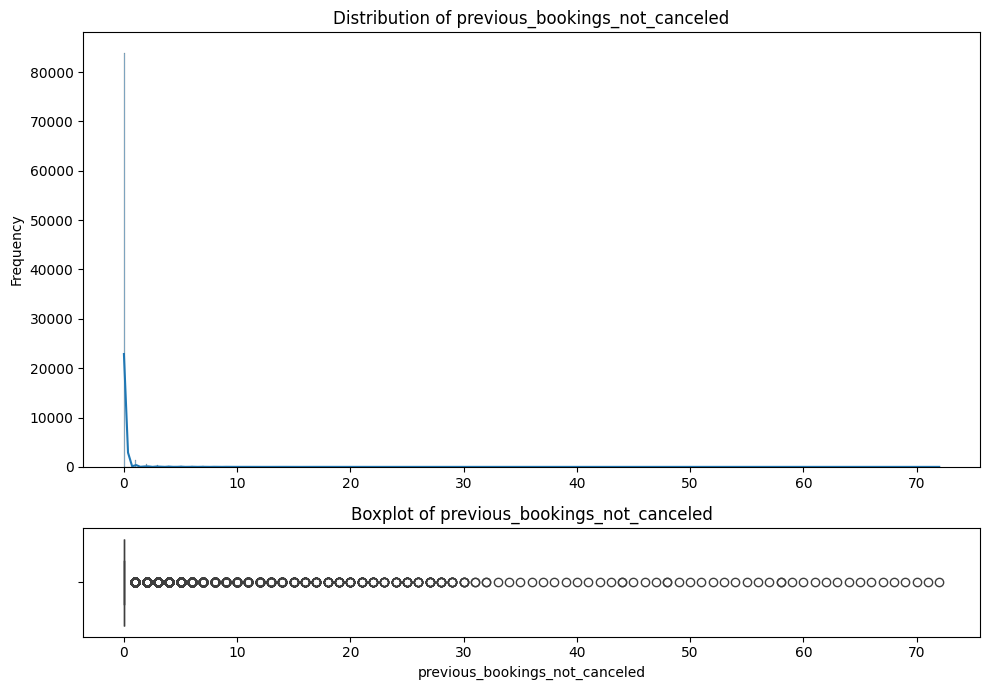

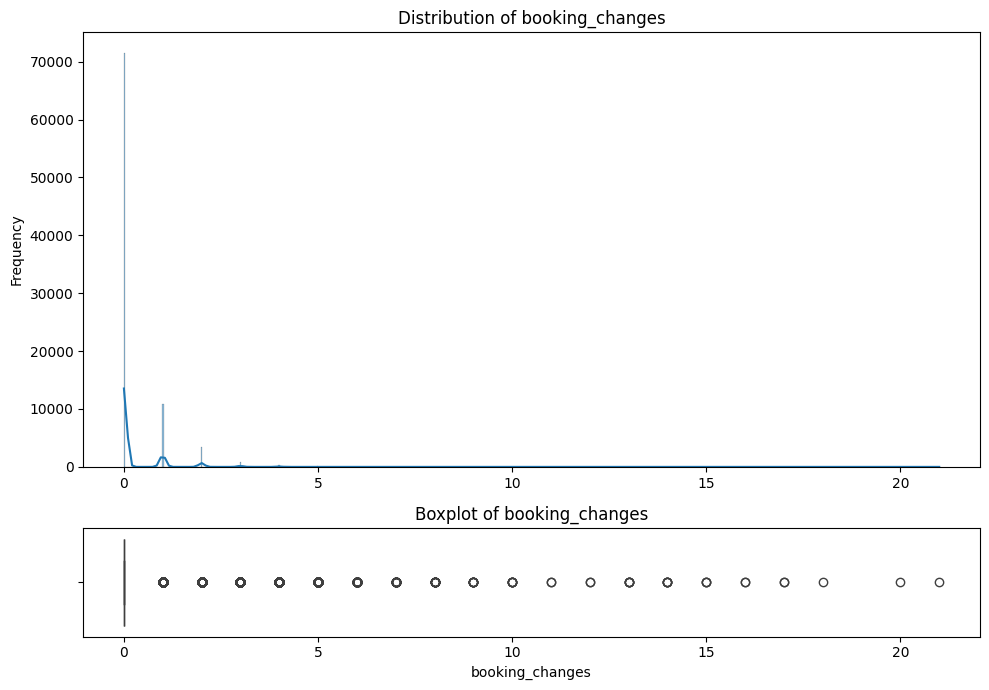

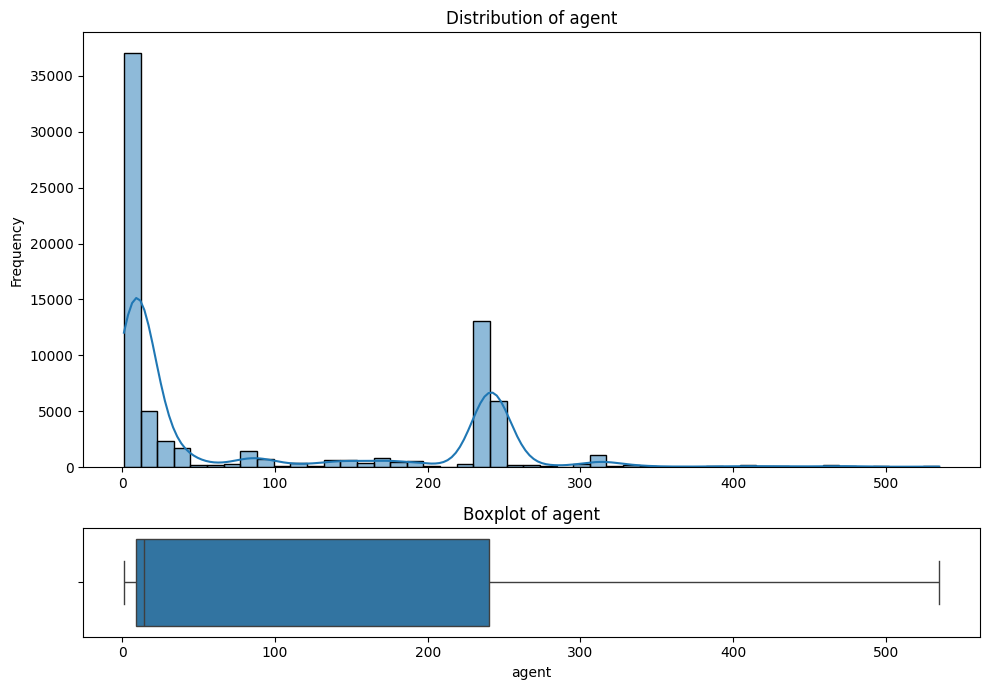

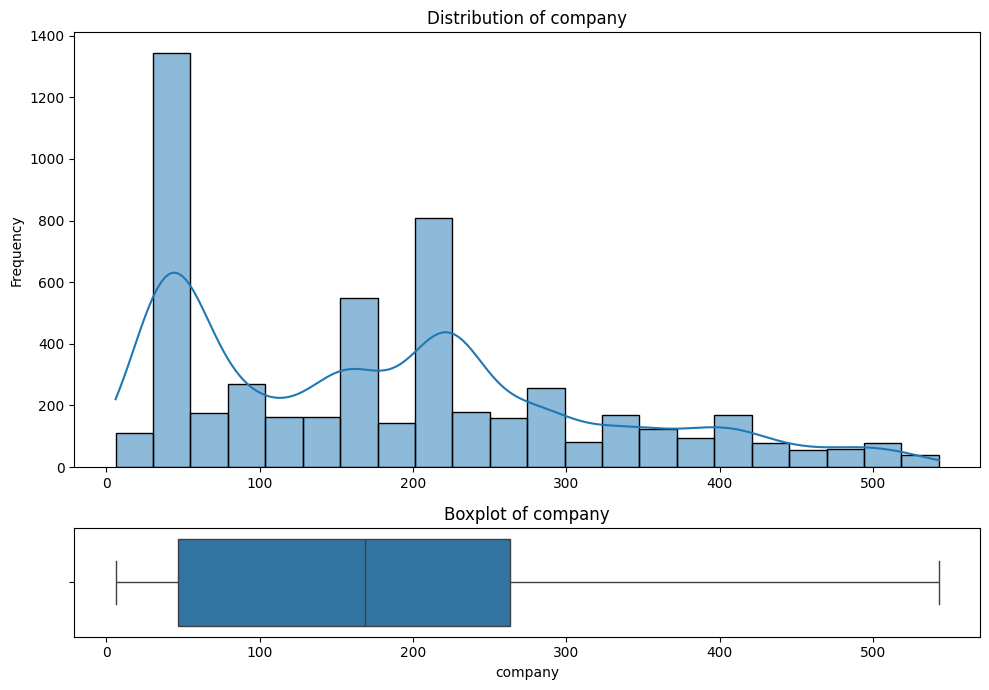

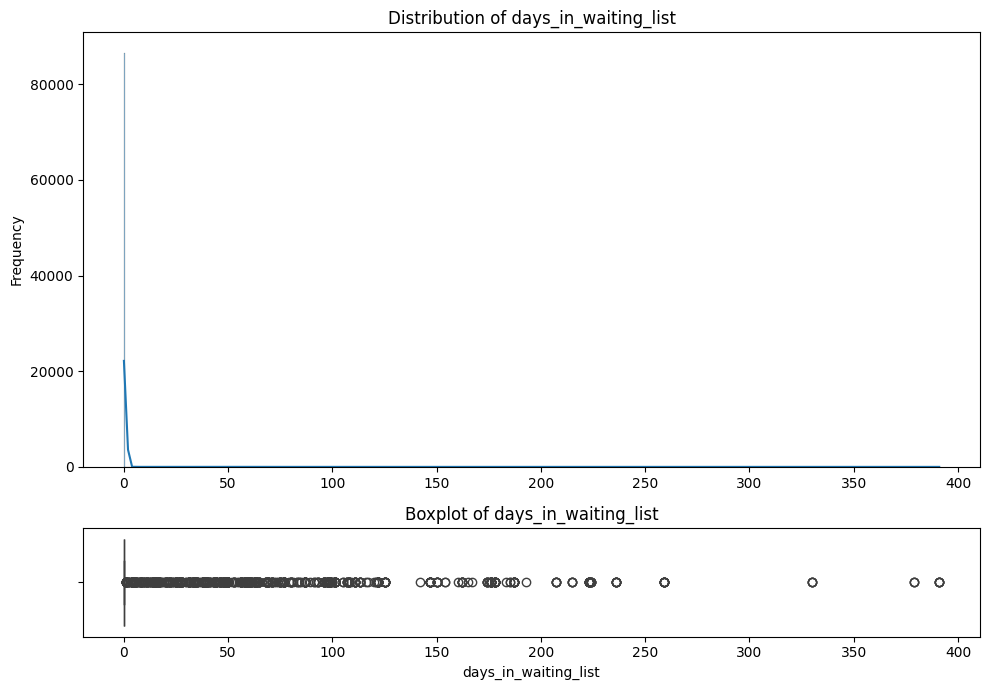

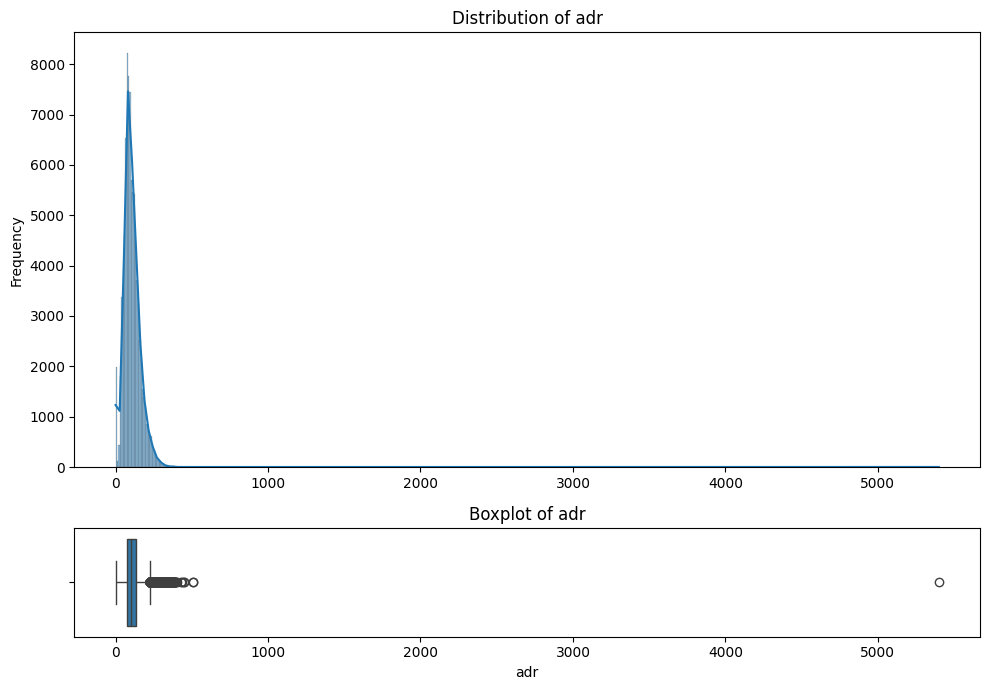

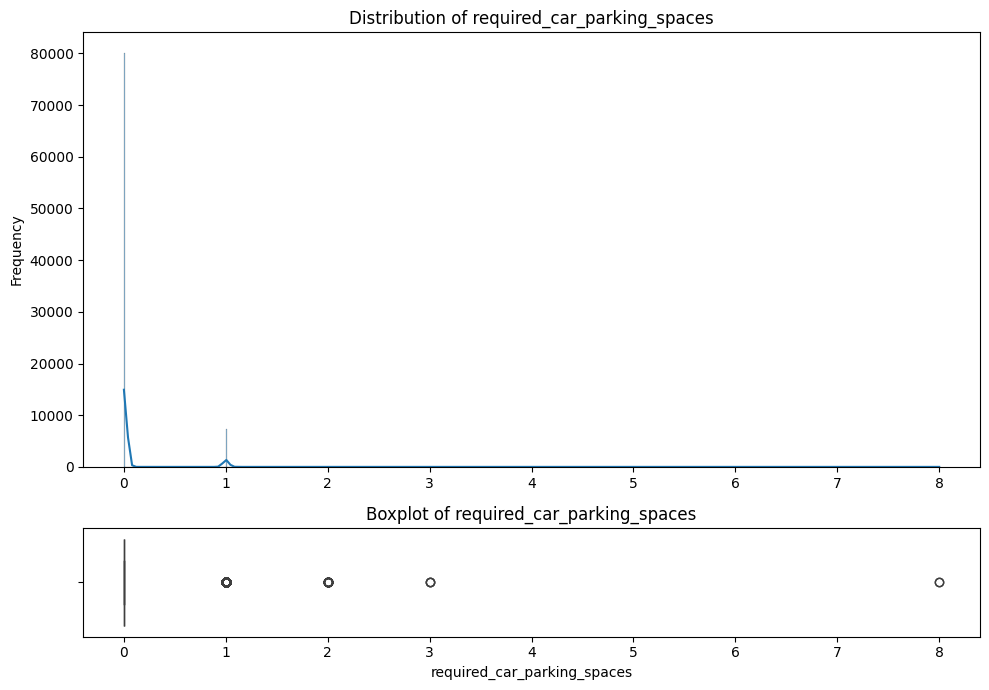

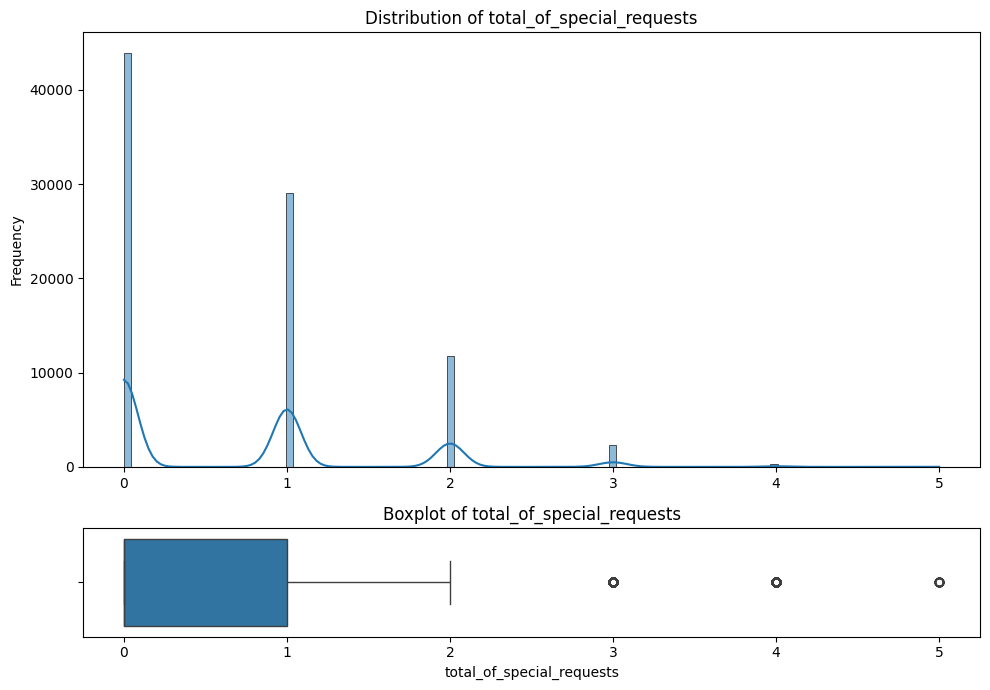

In [20]:
for col in numeric_columns:
    fig, axes = plt.subplots(
        2, 1,
        figsize=(10, 7),
        gridspec_kw={'height_ratios': [4, 1]}
    )

    
    sns.histplot(data=df, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Frequency')

    
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

In [21]:
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    percentage = len(outliers) / len(df) * 100

    print(
        f'{col}: {len(outliers)} outliers '
        f'({percentage:.2f}%)'
    )

is_canceled: 0 outliers (0.00%)
lead_time: 2396 outliers (2.74%)
arrival_date_year: 0 outliers (0.00%)
arrival_date_week_number: 0 outliers (0.00%)
arrival_date_day_of_month: 0 outliers (0.00%)
stays_in_weekend_nights: 220 outliers (0.25%)
stays_in_week_nights: 1531 outliers (1.75%)
adults: 22899 outliers (26.20%)
children: 8364 outliers (9.57%)
babies: 914 outliers (1.05%)
is_repeated_guest: 3415 outliers (3.91%)
previous_cancellations: 1685 outliers (1.93%)
previous_bookings_not_canceled: 3545 outliers (4.06%)
booking_changes: 15902 outliers (18.20%)
agent: 0 outliers (0.00%)
company: 0 outliers (0.00%)
days_in_waiting_list: 860 outliers (0.98%)
adr: 2490 outliers (2.85%)
required_car_parking_spaces: 7313 outliers (8.37%)
total_of_special_requests: 2673 outliers (3.06%)


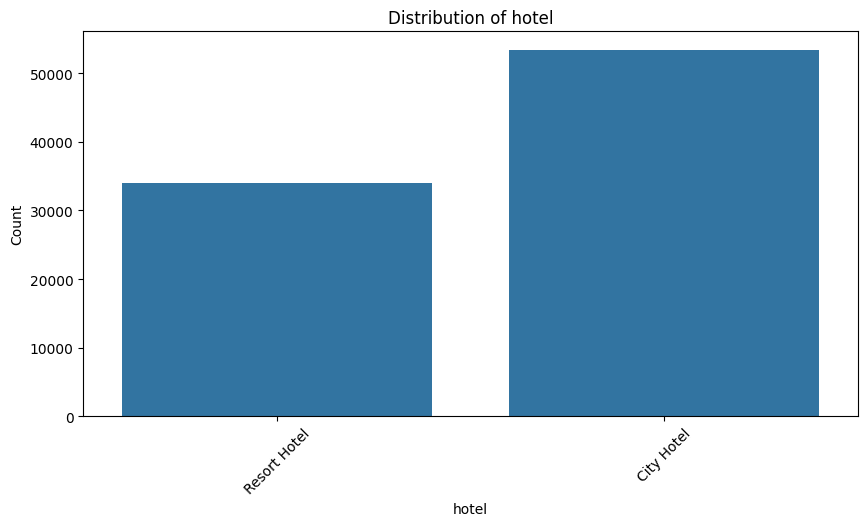

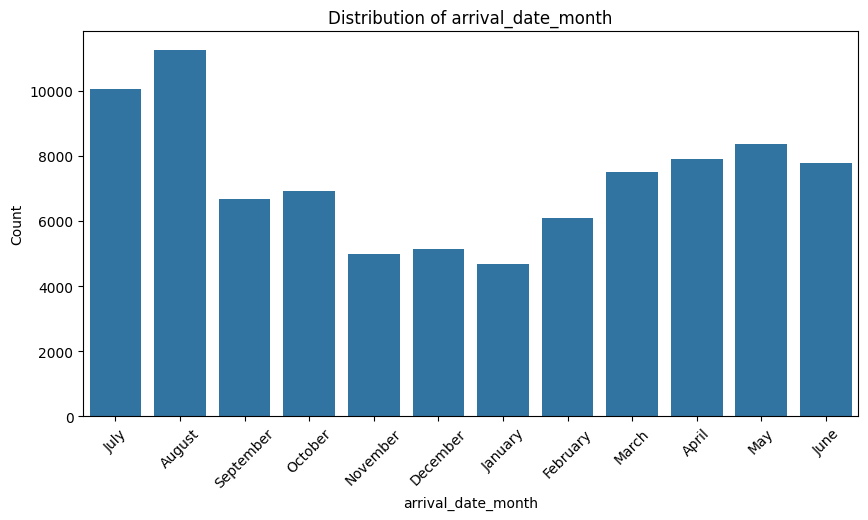

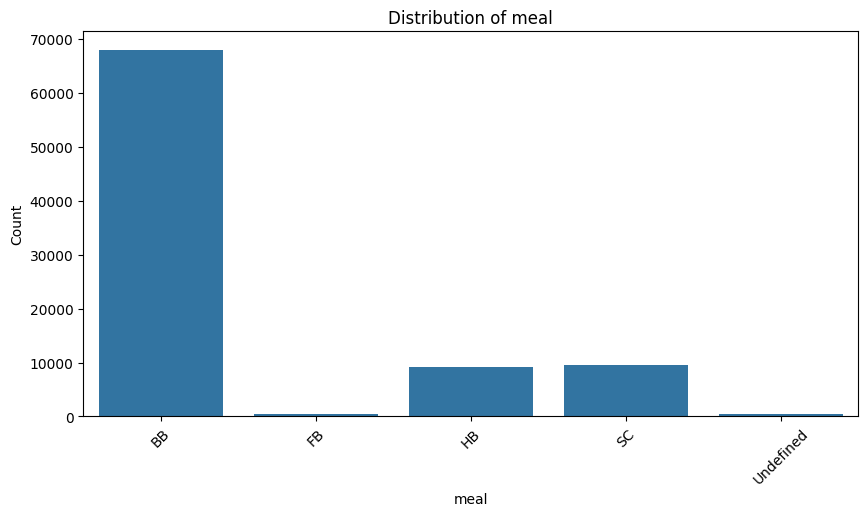

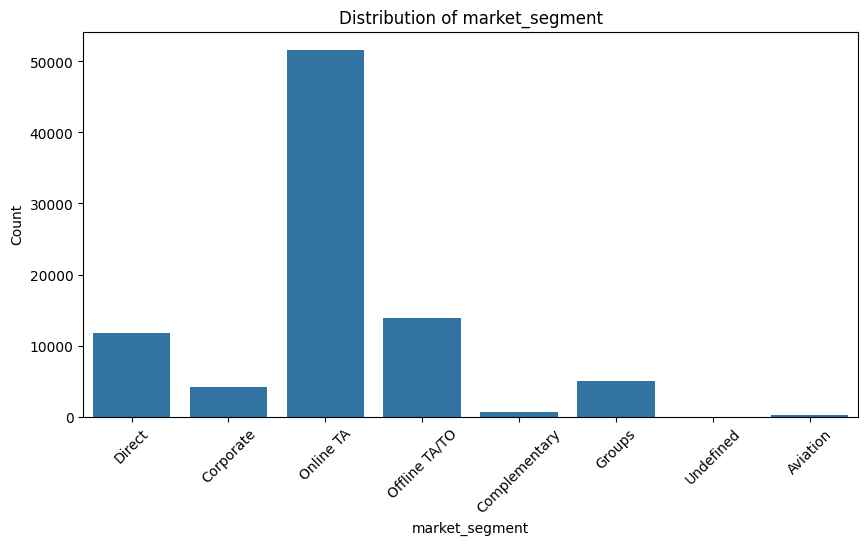

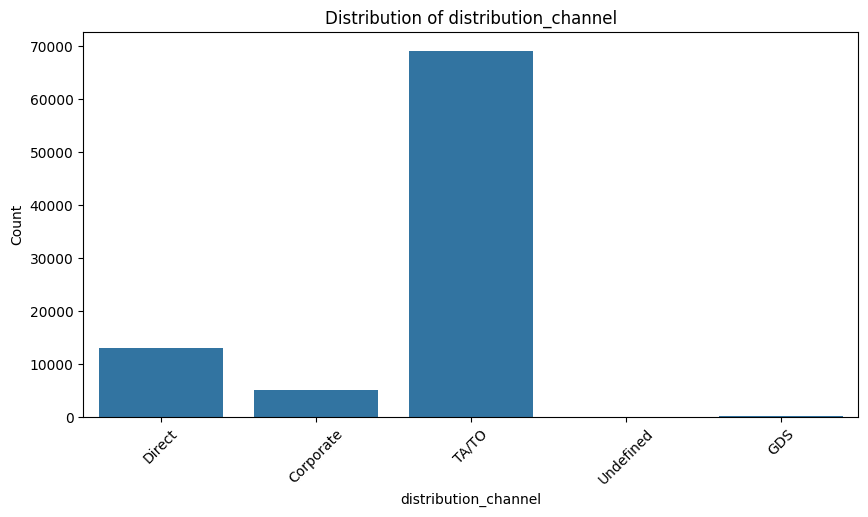

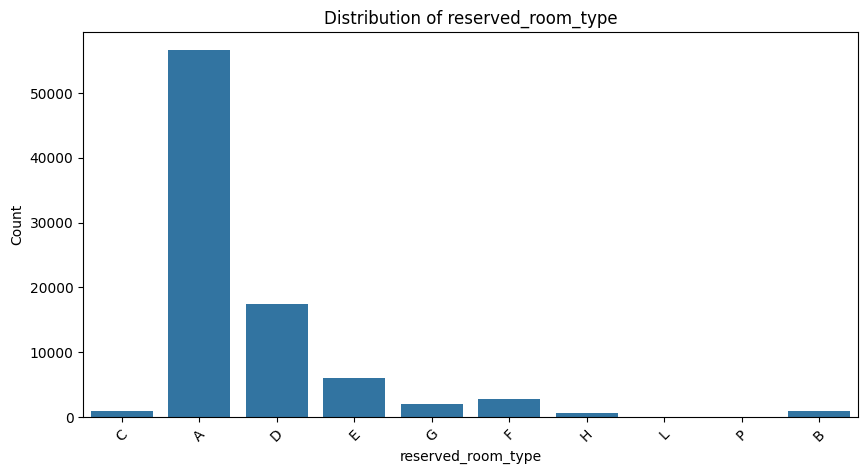

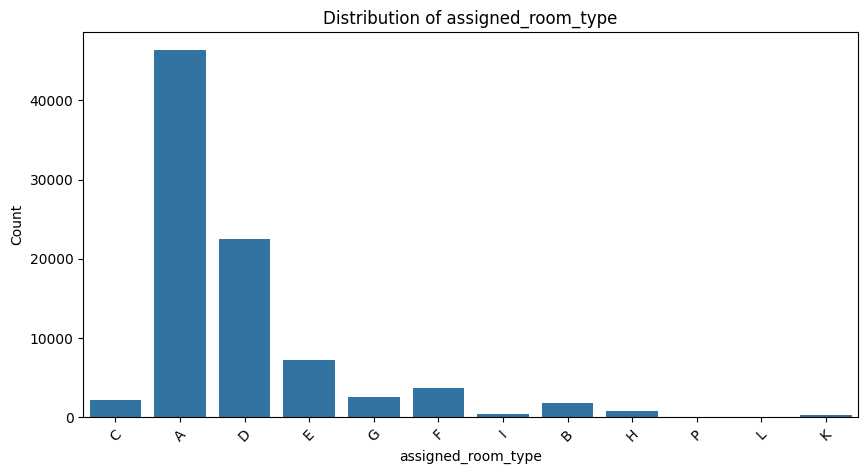

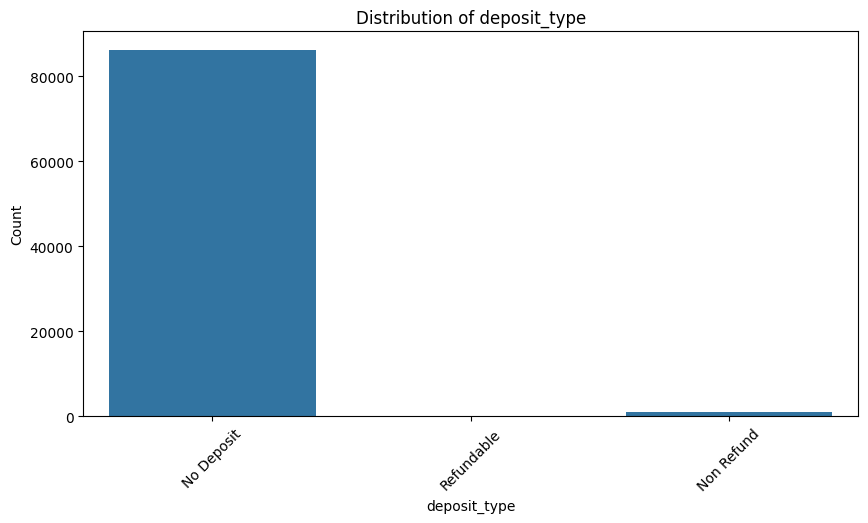

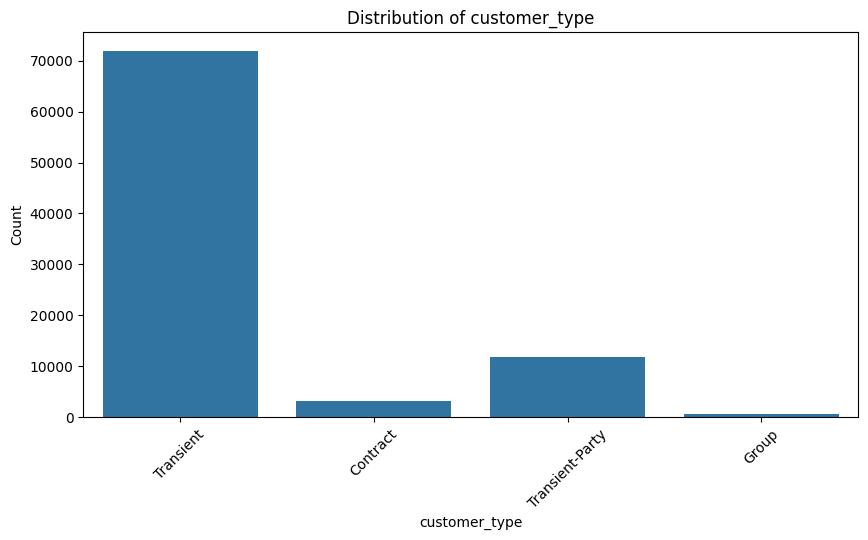

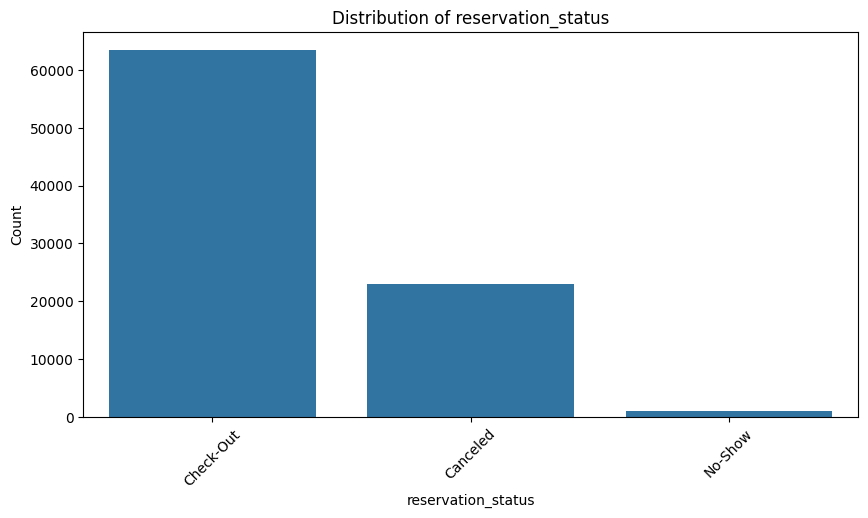

In [22]:
for col in categorical_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

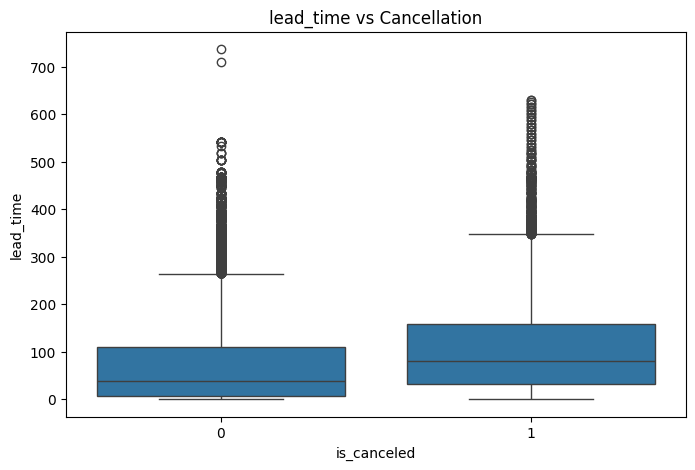

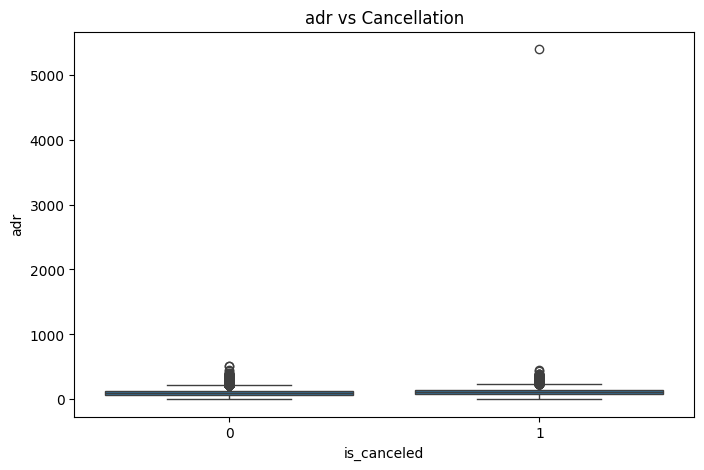

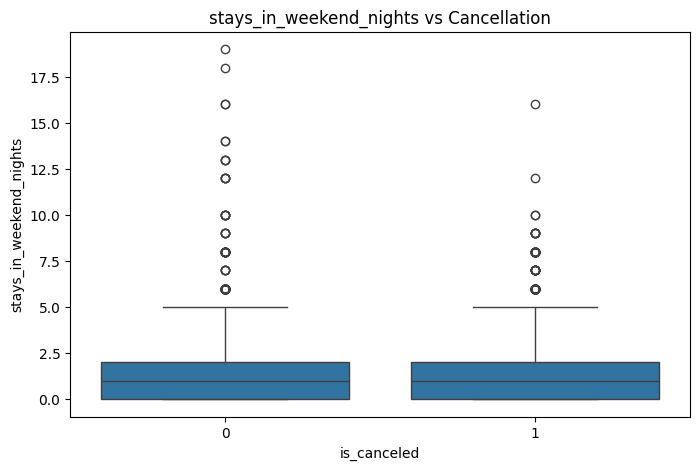

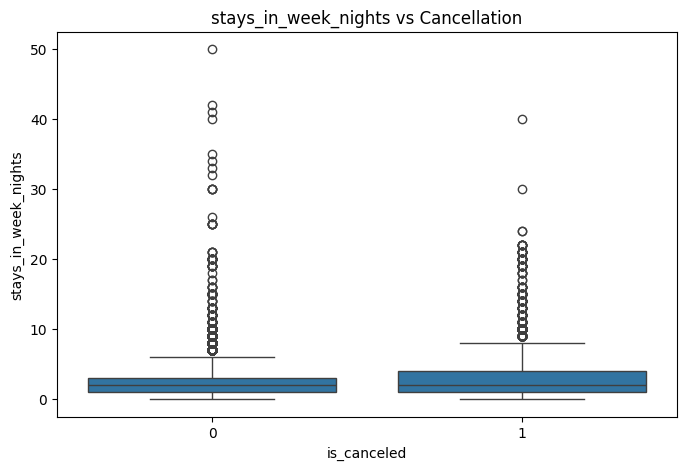

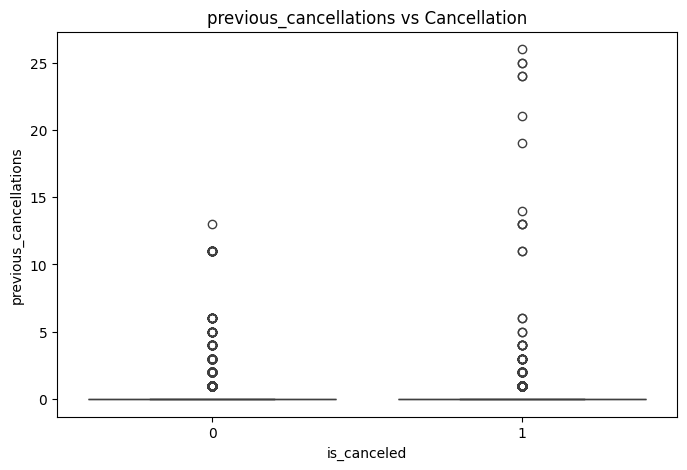

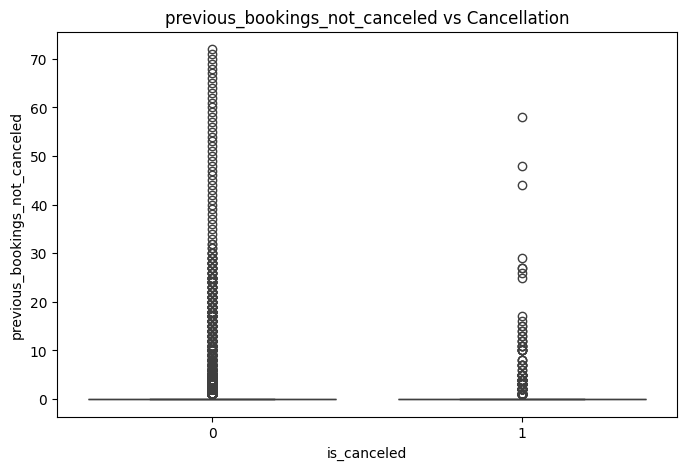

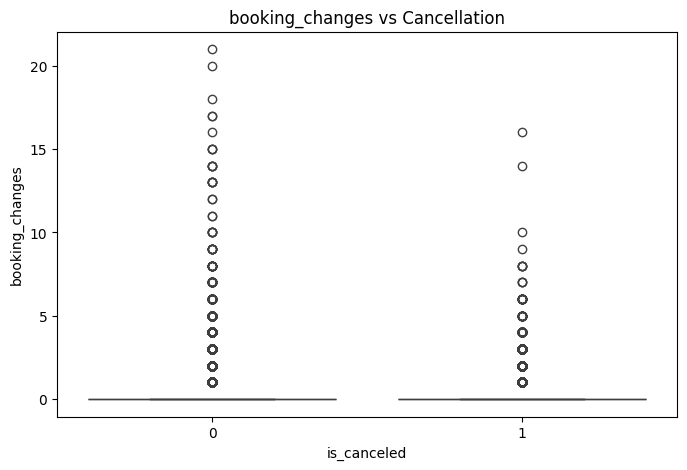

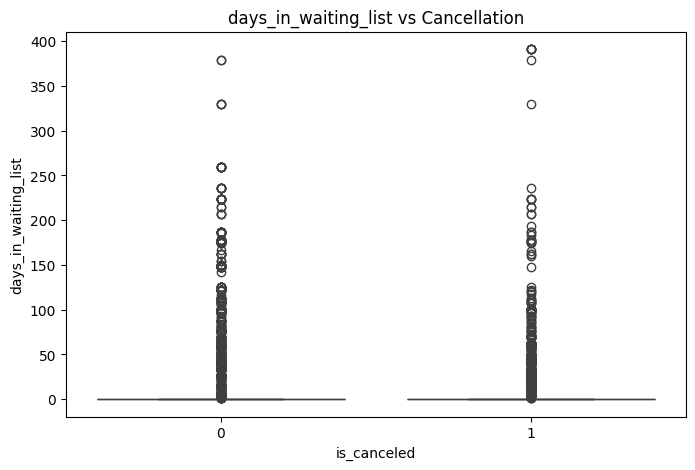

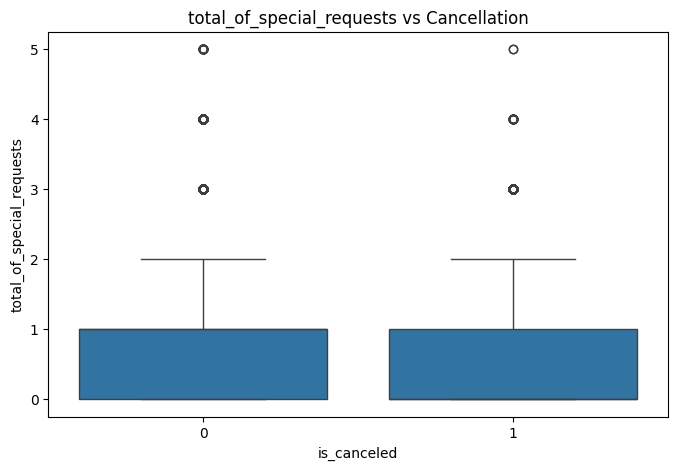

In [23]:
numeric_target_cols = [
    'lead_time',
    'adr',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'total_of_special_requests'
]

for col in numeric_target_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='is_canceled', y=col)
    plt.title(f'{col} vs Cancellation')
    plt.show()

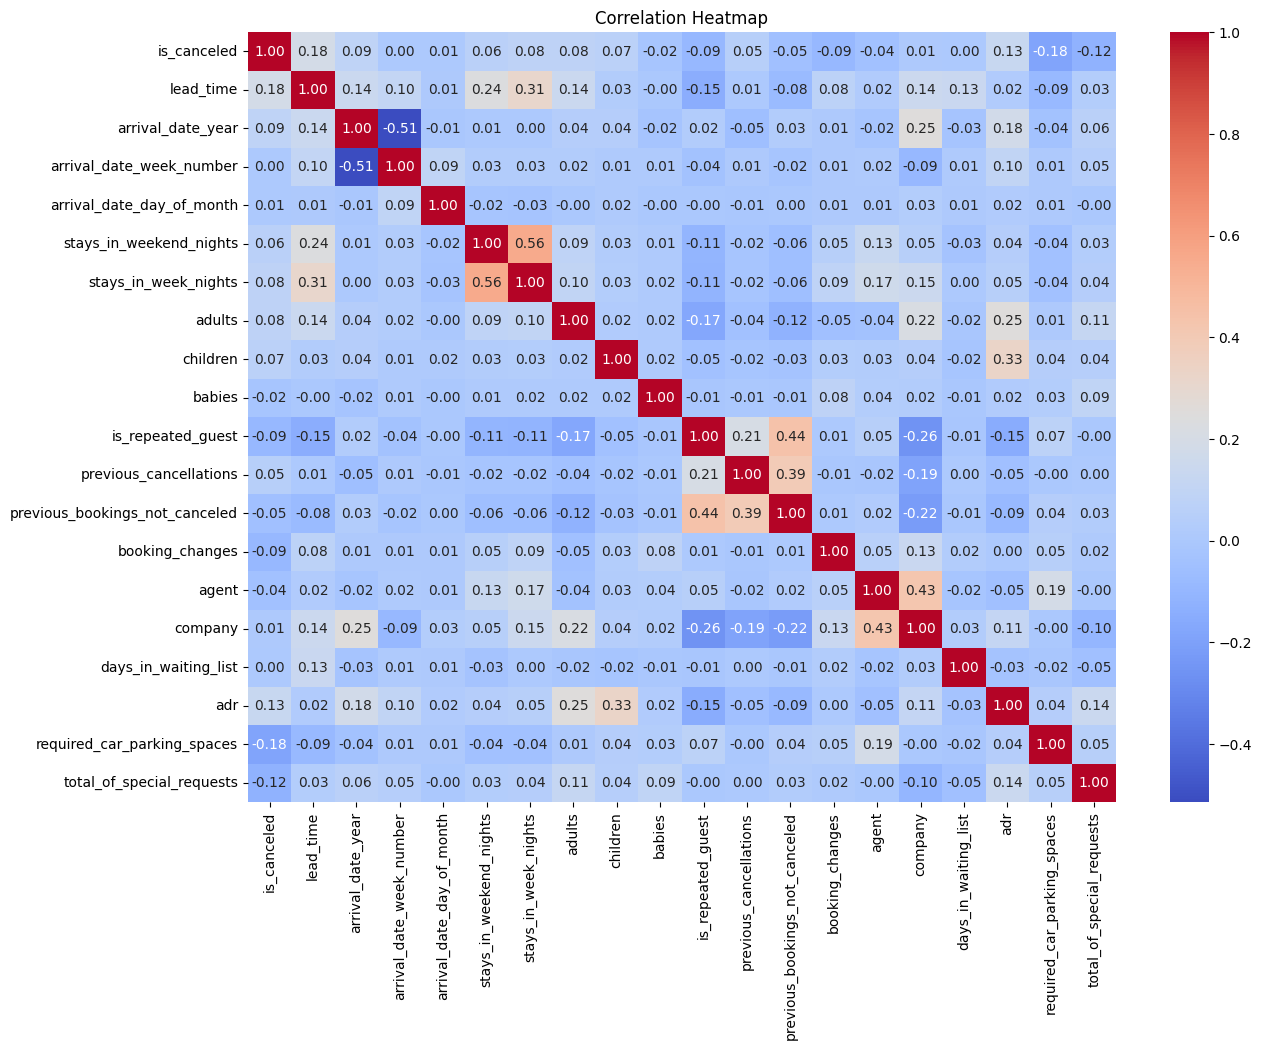

In [24]:
numeric_cols = df.select_dtypes(include='number').columns

corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [25]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [26]:
df = df.drop(['reservation_status', 'reservation_status_date'], axis=1)

In [27]:
df = df.drop('company', axis=1)

In [28]:
for col in df.columns:
    print(f'\nColumn: {col}')
    print(f'Number of unique: {df[col].nunique()}')
    print(f'Unique values: {df[col].unique()}')


Column: hotel
Number of unique: 2
Unique values: ['Resort Hotel' 'City Hotel']

Column: is_canceled
Number of unique: 2
Unique values: [0 1]

Column: lead_time
Number of unique: 479
Unique values: [342 737   7  13  14   0   9  85  75  23  35  68  18  37  12  72 127  78
  48  60  77  99 118  95  96  69  45  40  15  36  43  70  16 107  47 113
  90  50  93  76   3   1  10   5  17  51  71  63  62 101   2  81 368 364
 324  79  21 109 102   4  98  92  26  73 115  86  52  29  30  33  32   8
 100  44  80  97  64  39  34  27  82  94 110 111  84  66 104  28 258 112
  65  67  55  88  54 292  83 105 280 394  24 103 366 249  22  91  11 108
 106  31  87  41 304 117  59  53  58 116  42 321  38  56  49 317   6  57
  19  25 315 123  46  89  61 312 299 130  74 298 119  20 286 136 129 124
 327 131 460 140 114 139 122 137 126 120 128 135 150 143 151 132 125 157
 147 138 156 164 346 159 160 161 333 381 149 154 297 163 314 155 323 340
 356 142 328 144 336 248 302 175 344 382 146 170 166 338 167 310 148 165

### Data Preprocessing

In [29]:
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
numeric_features = [
    'lead_time',
    'arrival_date_year',
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]



In [32]:
categorical_features = [
    'hotel',
    'arrival_date_month',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    'customer_type',
    'agent'
]

In [33]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

In [34]:
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])
preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['lead_time', 'arrival_date_year',
                                  'arrival_date_week_number',
                                  'arrival_date_day_of_month',
                                  'stays_in_weekend_nights',
                                  'stays_in_week_nights', 'adults', 'children',
                                  'babies', 'is_repeated_guest',
                                  'previous_cancellations',
                                  'previo...
                                  'total_of_special_requests']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['hotel', 'arrival_date_month', 'meal',
                                  'country', 'market_segment',
                                  'distribution_channel', 'reserved_room_type',
                                  'assigned_room_type', 'deposit_type',
                                  'customer_type', 'agent'])])

In [35]:
X_train_transformed = preprocessor.fit_transform(X_train)

print(X_train_transformed.shape)

(69916, 568)


In [36]:
X_test_transformed = preprocessor.transform(X_test)

print(X_test_transformed.shape)

(17480, 568)


In [37]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['lead_time', 'arrival_date_year',
                                  'arrival_date_week_number',
                                  'arrival_date_day_of_month',
                                  'stays_in_weekend_nights',
                                  'stays_in_week_nights', 'adults', 'children',
                                  'babies', 'is_repeated_guest',
                                  'previous_cancellations',
                                  'previo...
                                  'total_of_special_requests']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['hotel', 'arrival_date_month', 'meal',
                                  'country', 'market_segment',
                                  'distribution_channel', 'reserved_room_type',
                                  'assigned_room_type', 'deposit_type',
                                  'customer_type', 'agent'])])

In [38]:
for name, transformer, columns in preprocessor.transformers_:
    print(f"\n{name}")
    print("Columns:")
    print(columns)


numeric
Columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

categorical
Columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'agent']


In [39]:
df['is_canceled'].value_counts(normalize=True) * 100

is_canceled
0    72.510184
1    27.489816
Name: proportion, dtype: float64

In [40]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print(scale_pos_weight)

2.637669094693028


In [41]:
models_pipelines = {
    'Logistic Regression': Pipeline([
        ('Model', LogisticRegression(
            random_state=42,
            class_weight='balanced'
        ))
    ]),

    'Decision Tree': Pipeline([
        ('Model', DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced'
        ))
    ]),

    'Random Forest': Pipeline([
        ('Model', RandomForestClassifier(
            random_state=42,
            class_weight='balanced'
        ))
    ]),

    'SVC': Pipeline([
        ('Model', SVC(
            random_state=42,
            class_weight='balanced'
        ))
    ]),

    'KNN': Pipeline([
        ('Model', KNeighborsClassifier())
    ]),

    'Gaussian NB': Pipeline([
        ('Model', GaussianNB())
    ]),

    'XGBoost': Pipeline([
        ('Model', XGBClassifier(
            random_state=42,
            scale_pos_weight=scale_pos_weight
        ))
    ])
}
print("Models and Pipelines:")
for model_name in models_pipelines.keys():
    print(f"- {model_name}")

Models and Pipelines:
- Logistic Regression
- Decision Tree
- Random Forest
- SVC
- KNN
- Gaussian NB
- XGBoost


In [ ]:
models = [

     ('Logistic Regression',
      LogisticRegression(
          random_state=42,
          class_weight='balanced',
          max_iter=2000
      )),

     ('Decision Tree',
      DecisionTreeClassifier(
          random_state=42,
          class_weight='balanced',
          max_depth=5
      )),

     ('Random Forest',
      RandomForestClassifier(
          random_state=42,
          class_weight='balanced',
          n_estimators=100,
          max_depth=10,
          n_jobs=-1
      )),

     ('SVC',
      SVC(
          random_state=42,
          class_weight='balanced',
          C=0.5,
          kernel='rbf',
          gamma='scale'
      )),

     ('KNN',
      KNeighborsClassifier()),

     ('Gaussian NB',
      GaussianNB()),

     ('XGBoost',
      XGBClassifier(
          random_state=42,
          scale_pos_weight=scale_pos_weight
      ))
 ]

 for name, model in models:

     model_pipeline = Pipeline([
         ('Preprocessing', preprocessor),
         ('Model', model)
     ])

     cv_result = cross_validate(
         estimator=model_pipeline,
         X=X_train,
         y=y_train,
         scoring=['precision', 'recall', 'f1', 'accuracy'],
         cv=5,
         return_train_score=True,
         n_jobs=-1
     )

     print(name)

     print(
         'Train Precision:',
         round(cv_result['train_precision'].mean() * 100, 2), '%'
     )

     print(
         'Validation Precision:',
         round(cv_result['test_precision'].mean() * 100, 2), '%'
     )

     print(
         'Train Recall:',
         round(cv_result['train_recall'].mean() * 100, 2), '%'
     )

     print(
         'Validation Recall:',
         round(cv_result['test_recall'].mean() * 100, 2), '%'
     )

     print(
         'Train F1 Score:',
         round(cv_result['train_f1'].mean() * 100, 2), '%'
     )

     print(
         'Validation F1 Score:',
         round(cv_result['test_f1'].mean() * 100, 2), '%'
     )

     print(
         'Train Accuracy:',
         round(cv_result['train_accuracy'].mean() * 100, 2), '%'
     )

     print(
         'Validation Accuracy:',
         round(cv_result['test_accuracy'].mean() * 100, 2), '%'
     )

print('-' * 60)

In [43]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, cross_val_predict
model_pipeline = Pipeline(steps= [('Preprocessing', preprocessor),
                                  ('Model', XGBClassifier(random_state= 42, scale_pos_weight = scale_pos_weight))])

y_train_proba = cross_val_predict(estimator= model_pipeline,
                                    X= X_train,
                                    y= y_train,
                                    cv= 5,
                                    method= 'predict_proba',
                                    n_jobs= -1
                                    )

In [44]:
y_train_proba = y_train_proba[:,1]
y_train_proba

array([0.70785856, 0.01078992, 0.9995517 , ..., 0.9341278 , 0.8363099 ,
       0.9228135 ], shape=(69916,), dtype=float32)

In [45]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_train, y_train_proba)

In [46]:
pr_df = pd.DataFrame({'Precision' : precision[:-1],
                      'Recall' : recall[:-1],
                      'Threshold' : thresholds})
pr_df

,Precision,Recall,Threshold
0,0.274901,1.000000,0.000003
1,0.274905,1.000000,0.000007
2,0.274909,1.000000,0.000007
3,0.274913,1.000000,0.000008
4,0.274917,1.000000,0.000008
...,...,...,...
69075,1.000000,0.000312,0.999966
69076,1.000000,0.000260,0.999968
69077,1.000000,0.000208,0.999971
69078,1.000000,0.000156,0.999972


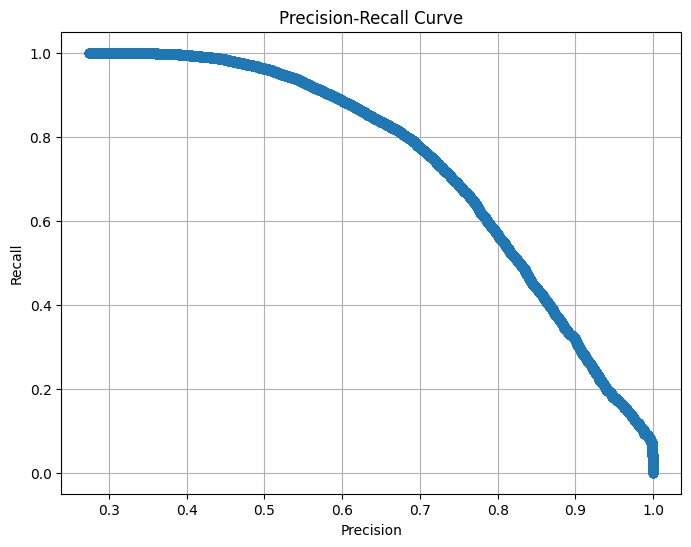

In [47]:
plt.figure(figsize=(8, 6))

plt.plot(
    pr_df['Precision'],
    pr_df['Recall'],
    marker='o'
)

plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title('Precision-Recall Curve')

plt.grid(True)
plt.show()

In [48]:
min_precision = 0.80
pr_df

,Precision,Recall,Threshold
0,0.274901,1.000000,0.000003
1,0.274905,1.000000,0.000007
2,0.274909,1.000000,0.000007
3,0.274913,1.000000,0.000008
4,0.274917,1.000000,0.000008
...,...,...,...
69075,1.000000,0.000312,0.999966
69076,1.000000,0.000260,0.999968
69077,1.000000,0.000208,0.999971
69078,1.000000,0.000156,0.999972


In [49]:
pr_df_filtered = pr_df[pr_df['Precision'] >= 0.80]
pr_df_filtered

,Precision,Recall,Threshold
55683,0.800015,0.567794,0.789674
55684,0.800000,0.567742,0.789691
55688,0.800015,0.567586,0.789739
55689,0.800000,0.567534,0.789741
55692,0.800029,0.567430,0.789796
...,...,...,...
69075,1.000000,0.000312,0.999966
69076,1.000000,0.000260,0.999968
69077,1.000000,0.000208,0.999971
69078,1.000000,0.000156,0.999972


In [50]:
pr_df_filtered.sort_values(by= ['Recall', 'Precision'], ascending= [False, False])

,Precision,Recall,Threshold
55683,0.800015,0.567794,0.789674
55684,0.800000,0.567742,0.789691
55688,0.800015,0.567586,0.789739
55689,0.800000,0.567534,0.789741
55693,0.800088,0.567430,0.789810
...,...,...,...
69075,1.000000,0.000312,0.999966
69076,1.000000,0.000260,0.999968
69077,1.000000,0.000208,0.999971
69078,1.000000,0.000156,0.999972


In [51]:
best_threshold = pr_df_filtered.loc[
    pr_df_filtered['Recall'].idxmax()
]

best_threshold

Precision    0.800015
Recall       0.567794
Threshold    0.789674
Name: 55683, dtype: float64

In [52]:
pr_df['F1'] = (
    2 * pr_df['Precision'] * pr_df['Recall']
    / (pr_df['Precision'] + pr_df['Recall'])
)

best_row = pr_df.loc[pr_df['F1'].idxmax()]

best_row

Precision    0.690700
Recall       0.790999
Threshold    0.597726
F1           0.737455
Name: 47424, dtype: float64

In [53]:
final_model = Pipeline([
    ('Preprocessing', preprocessor),
    ('Model', XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ))
])

final_model.fit(X_train, y_train)

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [54]:
y_test_proba = final_model.predict_proba(X_test)[:, 1]

In [55]:
best_threshold = 0.589397

y_test_pred = (y_test_proba >= best_threshold).astype(int)

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Test Accuracy :", round(accuracy_score(y_test, y_test_pred) * 100, 2), "%")
print("Test Precision:", round(precision_score(y_test, y_test_pred) * 100, 2), "%")
print("Test Recall   :", round(recall_score(y_test, y_test_pred) * 100, 2), "%")
print("Test F1 Score :", round(f1_score(y_test, y_test_pred) * 100, 2), "%")

Test Accuracy : 84.41 %
Test Precision: 68.54 %
Test Recall   : 80.0 %
Test F1 Score : 73.83 %


In [57]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89     12675
           1       0.69      0.80      0.74      4805

    accuracy                           0.84     17480
   macro avg       0.80      0.83      0.81     17480
weighted avg       0.85      0.84      0.85     17480



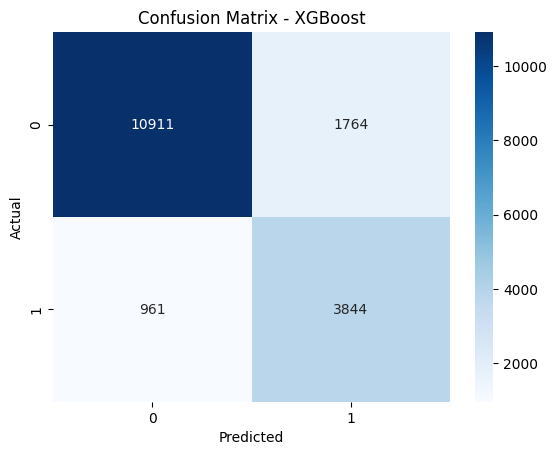

In [58]:
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

In [59]:
import joblib
joblib.dump(final_model, 'hotel_booking_xgboost_pipeline.pkl')

['hotel_booking_xgboost_pipeline.pkl']

In [60]:
import joblib

model = joblib.load("hotel_booking_xgboost_pipeline.pkl")

print("Model loaded successfully!")
print(type(model))

Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


In [61]:
sample = X_test.iloc[[0]]

probability = model.predict_proba(sample)[0, 1]

print("Cancellation Probability:", round(probability, 4))

Cancellation Probability: 0.0555


In [77]:
prediction = int(probability >= best_threshold)

print("Probability:", round(probability, 4))
print("Threshold:", best_threshold)
print("Prediction:", prediction)
print("Actual:", y_test.iloc[10])

Probability: 0.0555
Threshold: 0.589397
Prediction: 0
Actual: 0


In [79]:
y_prob = final_model.predict_proba(X_test)[:, 1]

y_pred_threshold = (y_prob >= best_threshold).astype(int)

In [80]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_threshold))
print(confusion_matrix(y_test, y_pred_threshold))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89     12675
           1       0.69      0.80      0.74      4805

    accuracy                           0.84     17480
   macro avg       0.80      0.83      0.81     17480
weighted avg       0.85      0.84      0.85     17480

[[10911  1764]
 [  961  3844]]


### data science

### Does booking a hotel room further in advance increase the likelihood of cancellation?

In [84]:
bins = [0, 30, 60, 120, 180, float('inf')]
labels = ['0-30', '31-60', '61-120', '121-180', '180+']

df['lead_time_group'] = pd.cut(
    df['lead_time'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [85]:
cancellation_rate = (
    df.groupby('lead_time_group')['is_canceled']
      .mean()
      .mul(100)
)

print(cancellation_rate)

lead_time_group
0-30       16.418427
31-60      31.621500
61-120     33.541980
121-180    35.091701
180+       39.736507
Name: is_canceled, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_464\4205734033.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('lead_time_group')['is_canceled']


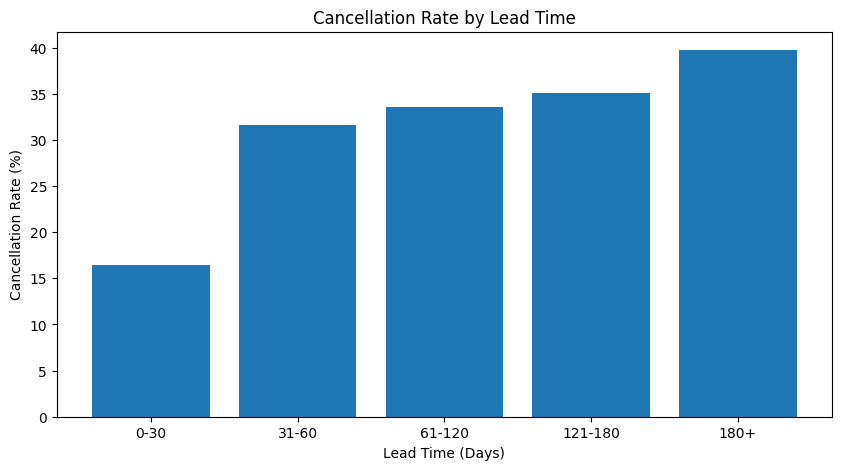

In [86]:
plt.figure(figsize=(10, 5))

plt.bar(
    cancellation_rate.index,
    cancellation_rate.values
)

plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Cancellation Rate (%)')

plt.show()

### Which market segments have the highest booking cancellation rates?

In [89]:
cancellation_by_segment = df.groupby('market_segment')['is_canceled'].mean() * 100
print(cancellation_by_segment)

market_segment
Aviation          19.823789
Complementary     12.535613
Corporate         12.108262
Direct            14.715351
Groups            27.013355
Offline TA/TO     14.853481
Online TA         35.346197
Undefined        100.000000
Name: is_canceled, dtype: float64


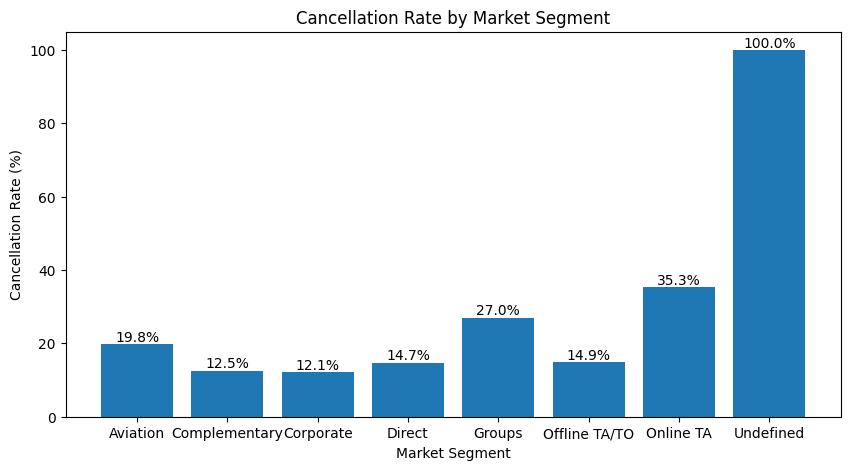

In [91]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    cancellation_by_segment.index,
    cancellation_by_segment.values
)

plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [93]:
cancellation_by_deposit_type = df.groupby('deposit_type')['is_canceled'].mean() * 100
print(cancellation_by_deposit_type)

deposit_type
No Deposit    26.684908
Non Refund    94.701349
Refundable    24.299065
Name: is_canceled, dtype: float64


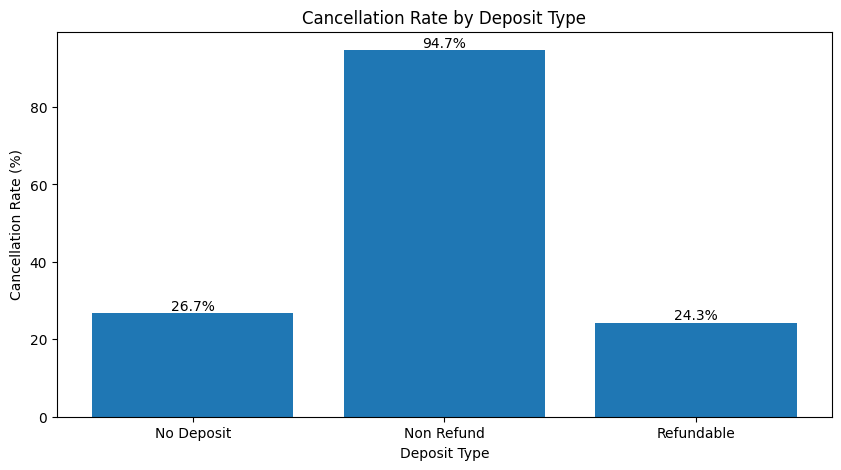

In [94]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    cancellation_by_deposit_type.index,
    cancellation_by_deposit_type.values
)

plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()


In [96]:
cancellation_by_is_repeated_guest = df.groupby('is_repeated_guest')['is_canceled'].mean() * 100
print(cancellation_by_is_repeated_guest)

is_repeated_guest
0    28.296877
1     7.642753
Name: is_canceled, dtype: float64


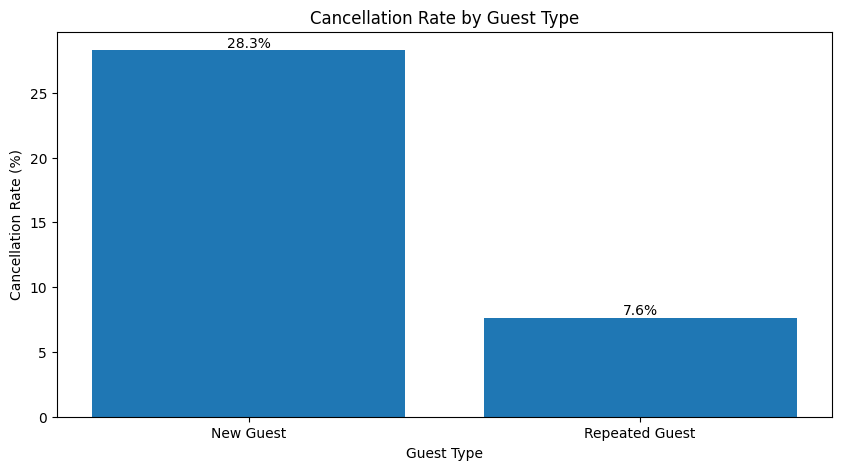

In [98]:
plt.figure(figsize=(10, 5))

labels = ['New Guest', 'Repeated Guest']

bars = plt.bar(
    labels,
    cancellation_by_is_repeated_guest.values
)

plt.title('Cancellation Rate by Guest Type')
plt.xlabel('Guest Type')
plt.ylabel('Cancellation Rate (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [99]:
cancellation_by_customer_type = df.groupby('customer_type')['is_canceled'].mean() * 100
print(cancellation_by_customer_type)

customer_type
Contract           16.310927
Group               9.926471
Transient          30.105854
Transient-Party    15.238339
Name: is_canceled, dtype: float64


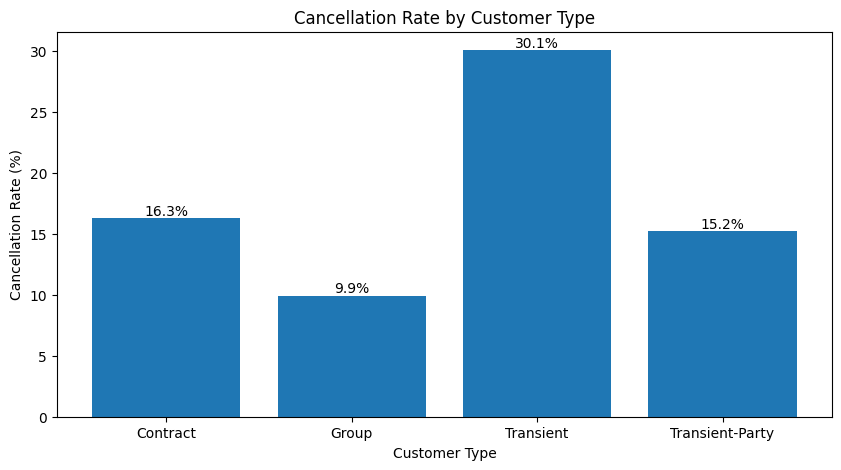

In [100]:
plt.figure(figsize=(10, 5))
labels = cancellation_by_customer_type.index
bars = plt.bar(
    labels,
    cancellation_by_customer_type.values
)
plt.title('Cancellation Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate (%)')
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )
plt.show()


In [106]:
adr_by_market_segment = df.groupby('market_segment')['adr'].mean()
print(adr_by_market_segment)

market_segment
Aviation         100.170396
Complementary      3.049245
Corporate         68.151246
Direct           116.579429
Groups            74.880727
Offline TA/TO     81.764191
Online TA        118.171606
Undefined         15.000000
Name: adr, dtype: float64


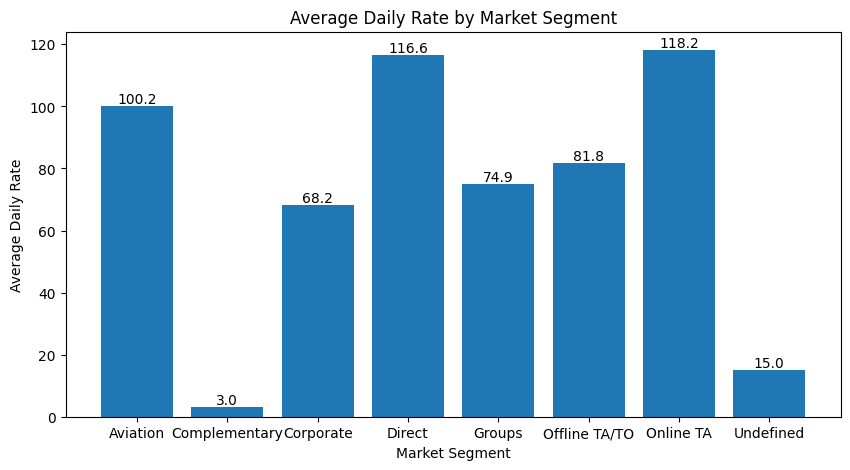

In [107]:
plt.figure(figsize=(10, 5))
bars = plt.bar(
    adr_by_market_segment.index,
    adr_by_market_segment.values
)
plt.title('Average Daily Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Average Daily Rate')
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}',
        ha='center',
        va='bottom'
    )
plt.show()

In [110]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
print(df['total_nights'])

0         0
1         0
2         1
3         1
4         2
         ..
119385    7
119386    7
119387    7
119388    7
119389    9
Name: total_nights, Length: 87396, dtype: int64


In [112]:
df['stay_length_group'] = pd.cut(
    df['total_nights'],
    bins=[0, 2, 5, 10, float('inf')],
    labels=['1-2 nights', '3-5 nights', '6-10 nights', '10+ nights']
)

In [113]:
cancellation_by_stay_length = (
    df.groupby('stay_length_group', observed=True)['is_canceled'].mean() * 100
)

print(cancellation_by_stay_length)

stay_length_group
1-2 nights     22.369340
3-5 nights     30.233777
6-10 nights    32.402886
10+ nights     33.419288
Name: is_canceled, dtype: float64


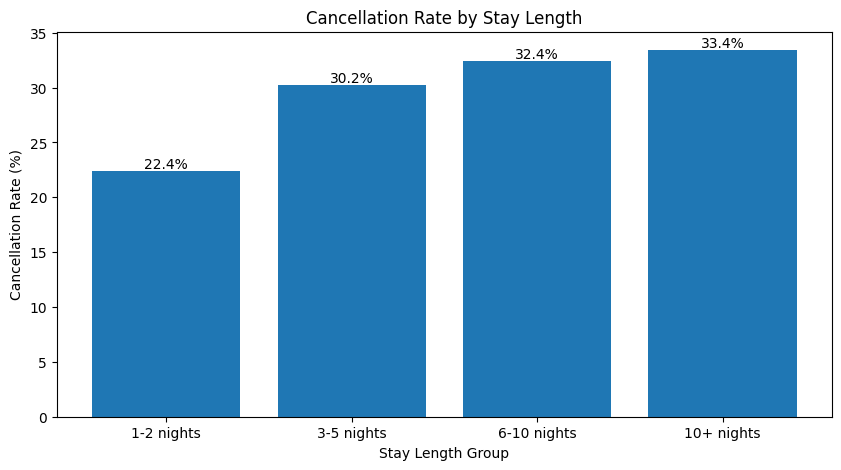

In [114]:
plt.figure(figsize=(10, 5))
bars = plt.bar(
    cancellation_by_stay_length.index,
    cancellation_by_stay_length.values
)
plt.title('Cancellation Rate by Stay Length')
plt.xlabel('Stay Length Group')
plt.ylabel('Cancellation Rate (%)')
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )
plt.show()

In [115]:
df['lead_time_group'] = pd.cut(
    df['lead_time'],
    bins=[0, 30, 60, 120, 180, float('inf')],
    labels=['0-30', '31-60', '61-120', '121-180', '180+'],
    include_lowest=True
)

In [116]:
cancellation_by_lead_time = df.groupby('lead_time_group')['is_canceled'].mean() * 100
print(cancellation_by_lead_time)

lead_time_group
0-30       16.418427
31-60      31.621500
61-120     33.541980
121-180    35.091701
180+       39.736507
Name: is_canceled, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_464\923749182.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancellation_by_lead_time = df.groupby('lead_time_group')['is_canceled'].mean() * 100


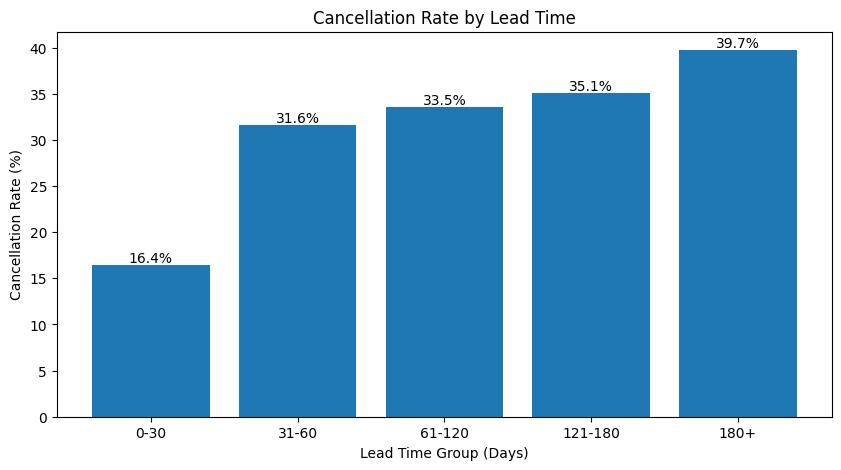

In [117]:
plt.figure(figsize=(10, 5))
bars = plt.bar(
    cancellation_by_lead_time.index,
    cancellation_by_lead_time.values
)
plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time Group (Days)')
plt.ylabel('Cancellation Rate (%)')
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )
plt.show()

In [118]:
cancellation_by_distribution_channel = df.groupby('distribution_channel')['is_canceled'].mean() * 100
print(cancellation_by_distribution_channel)

distribution_channel
Corporate    12.753395
Direct       14.821374
GDS          19.889503
TA/TO        30.968600
Undefined    80.000000
Name: is_canceled, dtype: float64


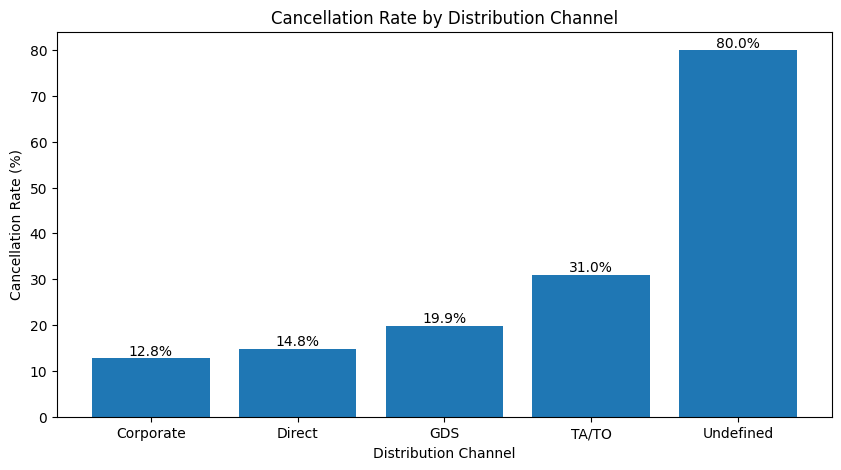

In [120]:
plt.figure(figsize=(10, 5))
bar = plt.bar(
    cancellation_by_distribution_channel.index,
    cancellation_by_distribution_channel.values
)
plt.title('Cancellation Rate by Distribution Channel')
plt.xlabel('Distribution Channel')
plt.ylabel('Cancellation Rate (%)')
for bar in bar:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )
plt.show()

In [121]:
cancellation_by_reserved_room_type = df.groupby('reserved_room_type')['is_canceled'].mean() * 100
print(cancellation_by_reserved_room_type)

reserved_room_type
A     25.970788
B     31.831832
C     32.349727
D     30.095413
E     27.260704
F     30.145236
G     35.916179
H     40.771812
L     33.333333
P    100.000000
Name: is_canceled, dtype: float64


In [123]:
booking_count_by_room = df['reserved_room_type'].value_counts()

print(booking_count_by_room)

reserved_room_type
A    56552
D    17398
E     6049
F     2823
G     2052
B      999
C      915
H      596
L        6
P        6
Name: count, dtype: int64


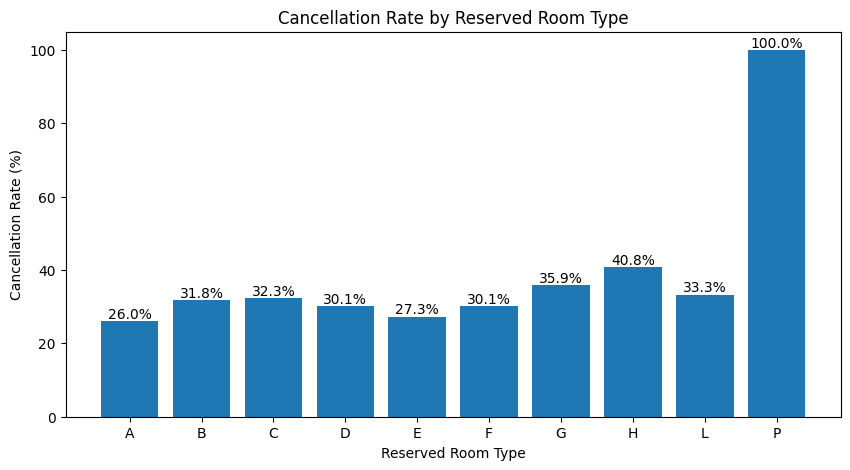

In [122]:
plt.figure(figsize=(10, 5))
bars = plt.bar(
    cancellation_by_reserved_room_type.index,
    cancellation_by_reserved_room_type.values
)
plt.title('Cancellation Rate by Reserved Room Type')
plt.xlabel('Reserved Room Type')
plt.ylabel('Cancellation Rate (%)')
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )
plt.show()

In [124]:
cancellation_by_meal = (df.groupby('meal')['is_canceled'].mean() * 100)

print(cancellation_by_meal)

meal
BB           26.548295
FB           27.500000
HB           26.967529
SC           35.302183
Undefined    16.666667
Name: is_canceled, dtype: float64


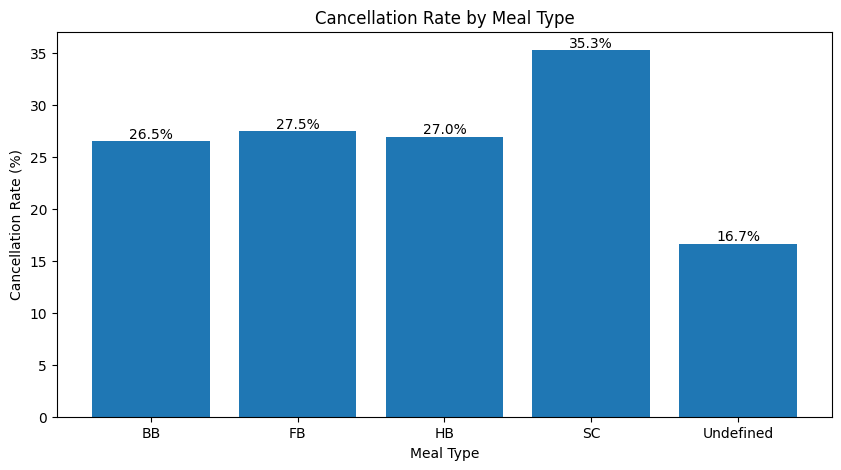

In [126]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    cancellation_by_meal.index,
    cancellation_by_meal.values
)

plt.title('Cancellation Rate by Meal Type')
plt.xlabel('Meal Type')
plt.ylabel('Cancellation Rate (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [127]:
cancellation_by_special_requests = (
    df.groupby('total_of_special_requests')['is_canceled'].mean() * 100
)

print(cancellation_by_special_requests)

total_of_special_requests
0    33.202716
1    22.411000
2    21.291907
3    17.134225
4    10.625000
5     5.555556
Name: is_canceled, dtype: float64


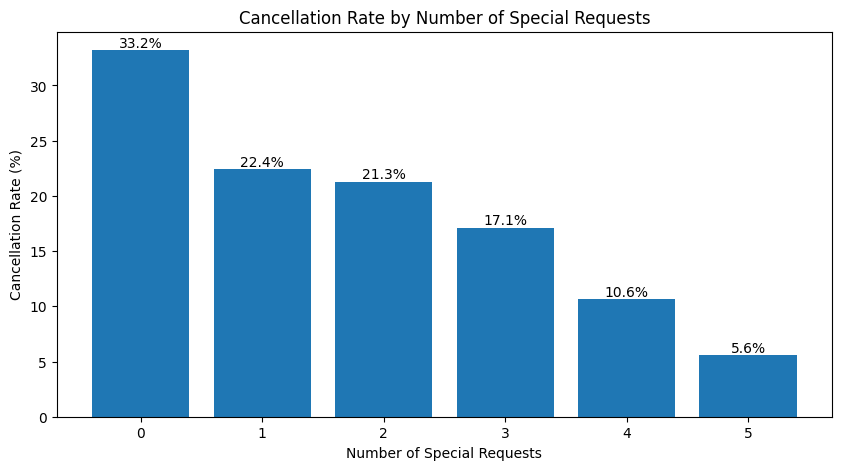

In [128]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    cancellation_by_special_requests.index,
    cancellation_by_special_requests.values
)

plt.title('Cancellation Rate by Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [130]:
df['booking_changes_group'] = pd.cut(
    df['booking_changes'],
    bins=[-1, 0, 2, 5, float('inf')],
    labels=['0 changes', '1-2 changes', '3-5 changes', '6+ changes']
)

In [131]:
cancellation_by_booking_changes = (
    df.groupby('booking_changes_group', observed=True)['is_canceled'].mean() * 100
)

print(cancellation_by_booking_changes)

booking_changes_group
0 changes      30.167567
1-2 changes    15.371270
3-5 changes    15.887157
6+ changes     19.310345
Name: is_canceled, dtype: float64


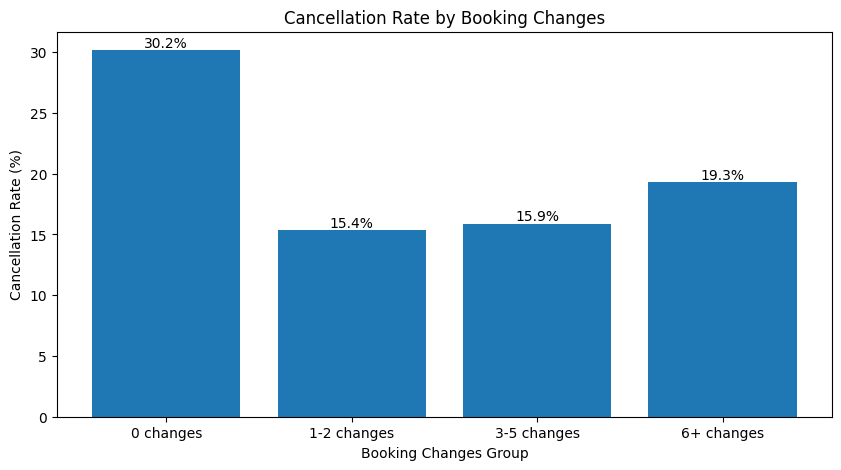

In [132]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    cancellation_by_booking_changes.index,
    cancellation_by_booking_changes.values
)

plt.title('Cancellation Rate by Booking Changes')
plt.xlabel('Booking Changes Group')
plt.ylabel('Cancellation Rate (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [134]:
df['previous_cancellations_group'] = pd.cut(
    df['previous_cancellations'],
    bins=[-1, 0, 1, float('inf')],
    labels=['0 cancellations', '1 cancellation', '2+ cancellations']
)

In [135]:
cancellation_by_previous_cancellations = (
    df.groupby(
        'previous_cancellations_group',
        observed=True
    )['is_canceled'].mean() * 100
)

print(cancellation_by_previous_cancellations)

previous_cancellations_group
0 cancellations     26.695523
1 cancellation      76.119403
2+ cancellations    26.258993
Name: is_canceled, dtype: float64


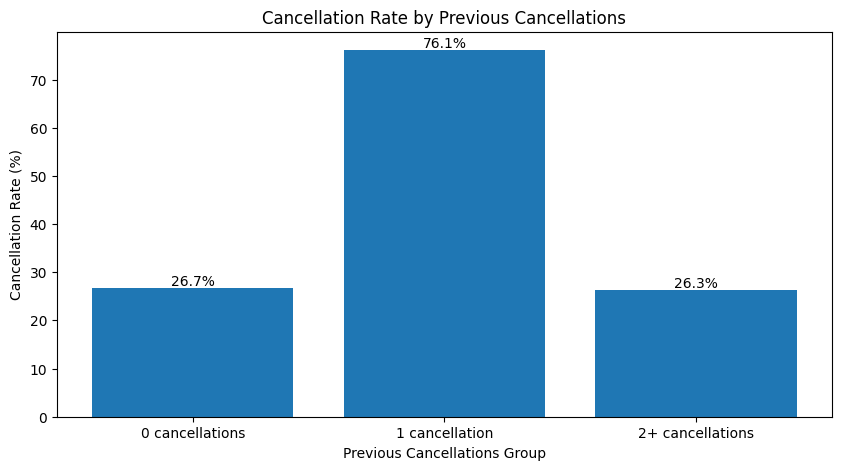

In [136]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    cancellation_by_previous_cancellations.index,
    cancellation_by_previous_cancellations.values
)

plt.title('Cancellation Rate by Previous Cancellations')
plt.xlabel('Previous Cancellations Group')
plt.ylabel('Cancellation Rate (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [138]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

bookings_by_month = (
    df.groupby('arrival_date_month')['is_canceled']
      .count()
      .reindex(month_order)
)

print(bookings_by_month)

arrival_date_month
January       4693
February      6098
March         7513
April         7908
May           8355
June          7765
July         10057
August       11257
September     6690
October       6934
November      4995
December      5131
Name: is_canceled, dtype: int64


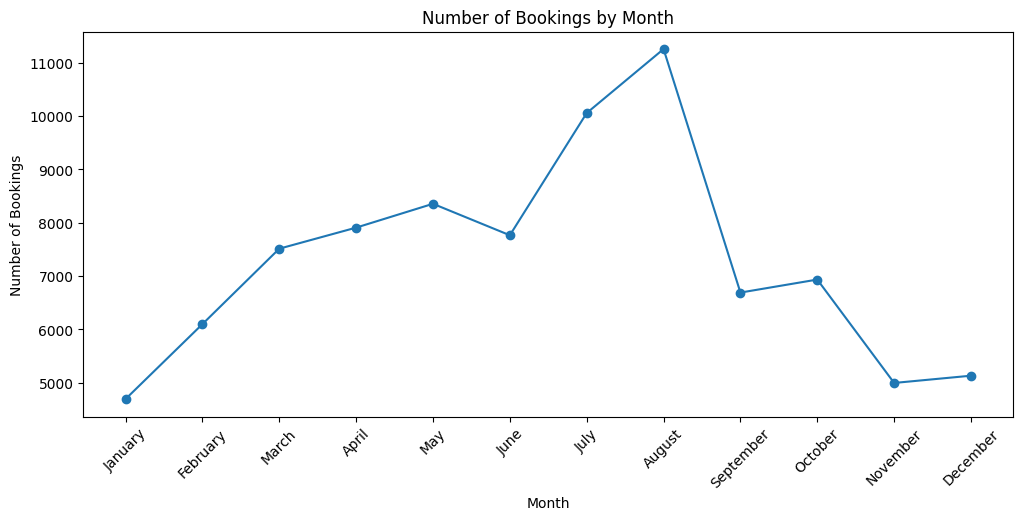

In [139]:
plt.figure(figsize=(12, 5))

plt.plot(
    bookings_by_month.index,
    bookings_by_month.values,
    marker='o'
)

plt.title('Number of Bookings by Month')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)

plt.show()

In [140]:
adr_by_month = (
    df.groupby('arrival_date_month')['adr'].mean()
    .reindex(month_order)
)

print(adr_by_month)

arrival_date_month
January       70.050742
February      74.692033
March         81.621237
April        103.612589
May          111.195703
June         119.750120
July         135.542014
August       150.876120
September    112.081263
October       90.152518
November      72.754460
December      81.450226
Name: adr, dtype: float64


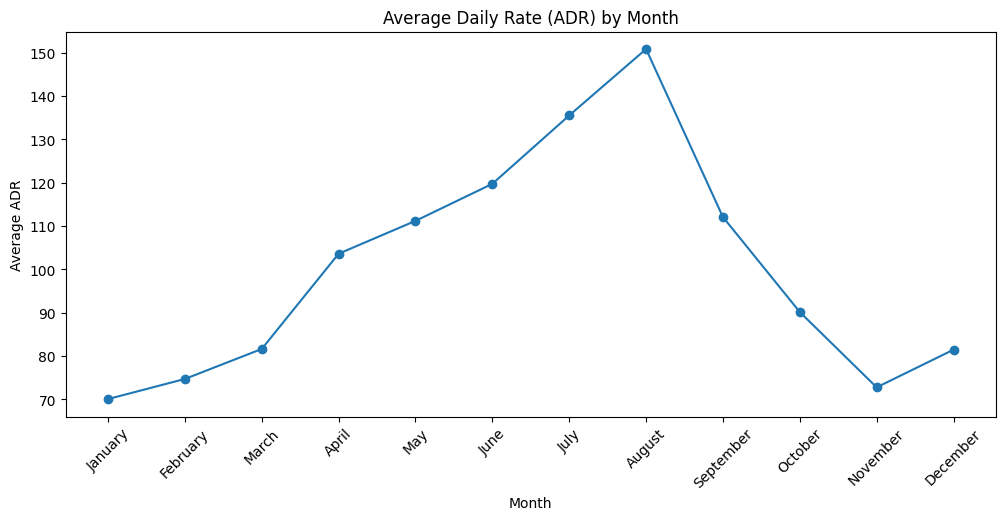

In [141]:
plt.figure(figsize=(12, 5))

plt.plot(
    adr_by_month.index,
    adr_by_month.values,
    marker='o'
)

plt.title('Average Daily Rate (ADR) by Month')
plt.xlabel('Month')
plt.ylabel('Average ADR')

plt.xticks(rotation=45)

plt.show()

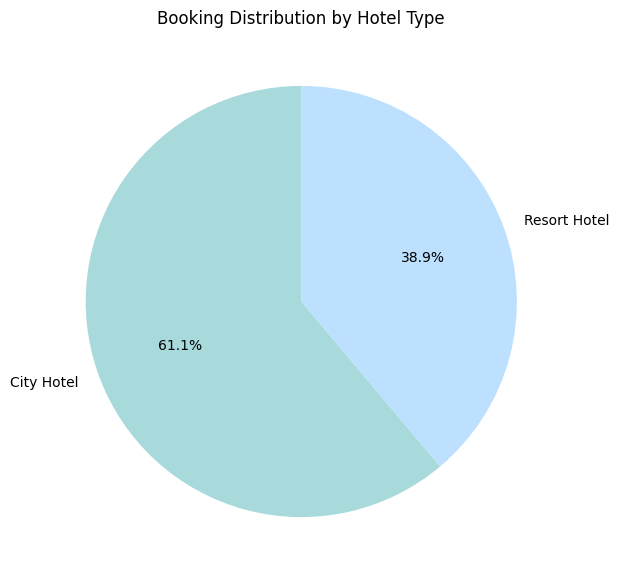

In [143]:
hotel_booking_count = df['hotel'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    hotel_booking_count.values,
    labels=hotel_booking_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#A8DADC', '#BDE0FE']
)

plt.title('Booking Distribution by Hotel Type')

plt.show()

In [144]:
bookings_by_country = df['country'].value_counts()

print(bookings_by_country.head(10))

country
PRT    27453
GBR    10433
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
Name: count, dtype: int64


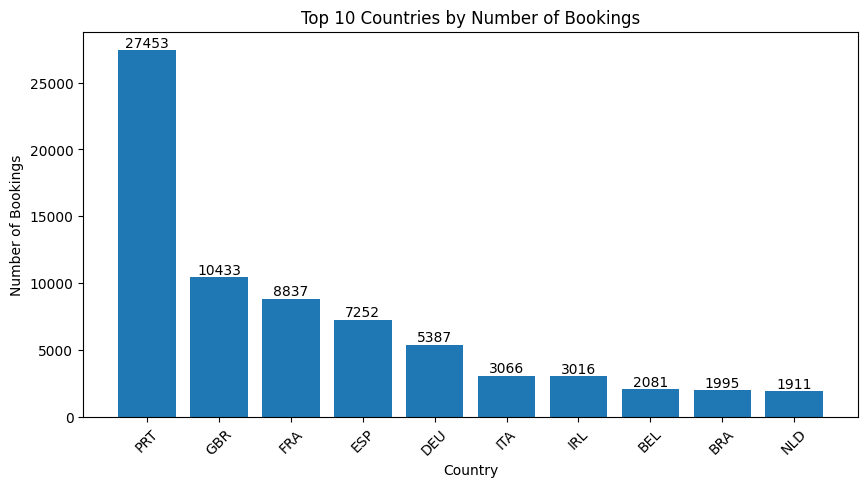

In [145]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    bookings_by_country.head(10).index,
    bookings_by_country.head(10).values
)

plt.title('Top 10 Countries by Number of Bookings')
plt.xlabel('Country')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height())}',
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
cancellation_by_hotel = df.groupby('hotel')['is_canceled'].mean() *100
print(cancellation_by_hotel)

hotel
City Hotel      30.038557
Resort Hotel    23.480923
Name: is_canceled, dtype: float64


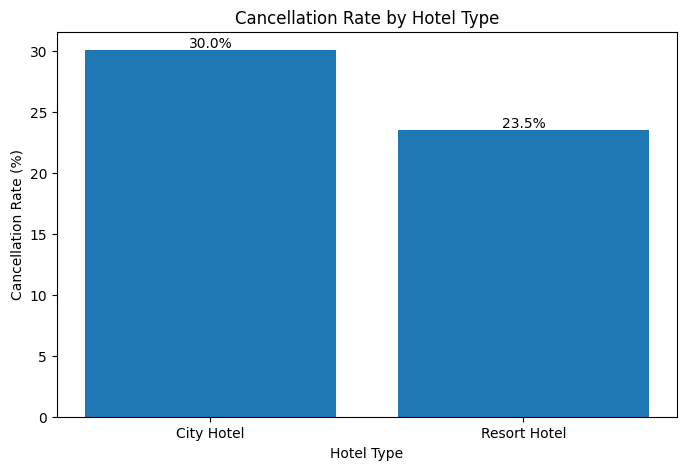

In [147]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    cancellation_by_hotel.index,
    cancellation_by_hotel.values
)

plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [148]:
adr_by_hotel = df.groupby('hotel')['adr'].mean()

print(adr_by_hotel)

hotel
City Hotel      110.985944
Resort Hotel     99.028449
Name: adr, dtype: float64


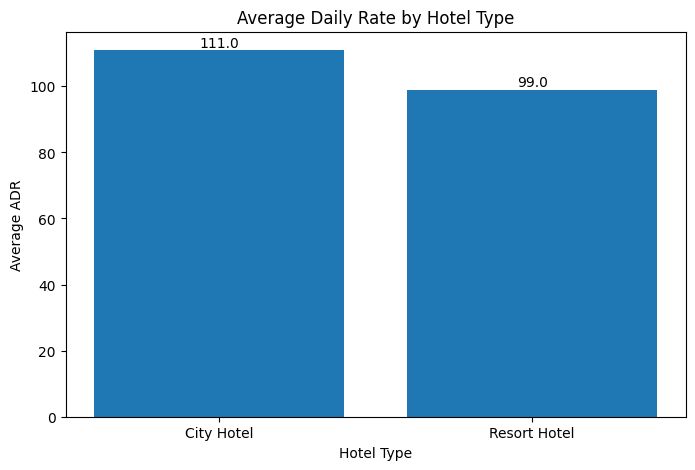

In [149]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    adr_by_hotel.index,
    adr_by_hotel.values
)

plt.title('Average Daily Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average ADR')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}',
        ha='center',
        va='bottom'
    )

plt.show()

In [151]:
parking_demand = df['required_car_parking_spaces'].apply(
    lambda x: 'Parking Required' if x > 0 else 'No Parking'
).value_counts()

print(parking_demand)

required_car_parking_spaces
No Parking          80083
Parking Required     7313
Name: count, dtype: int64


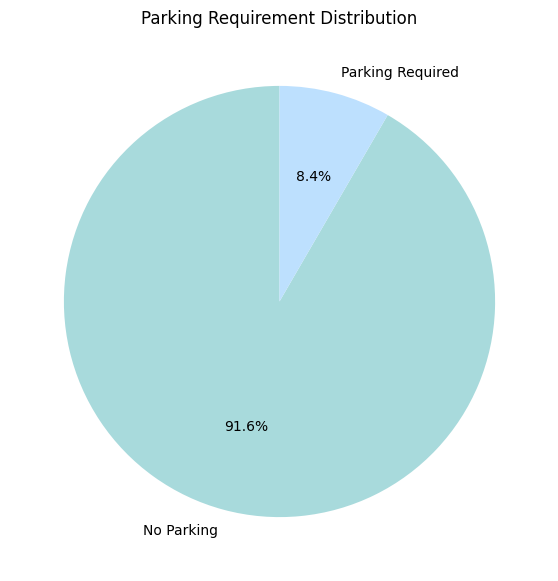

In [152]:
plt.figure(figsize=(7, 7))

plt.pie(
    parking_demand.values,
    labels=parking_demand.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#A8DADC', '#BDE0FE']
)

plt.title('Parking Requirement Distribution')

plt.show()

In [154]:
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

df['estimated_revenue'] = df['adr'] * df['total_nights']

In [155]:
revenue_by_segment = (
    df.groupby('market_segment')['estimated_revenue']
      .sum()
      .sort_values(ascending=False)
)

print(revenue_by_segment)

market_segment
Online TA        22266588.88
Offline TA/TO     5416727.59
Direct            4856818.92
Groups            1238547.76
Corporate          594164.08
Aviation            83033.36
Complementary        5074.52
Undefined              48.00
Name: estimated_revenue, dtype: float64


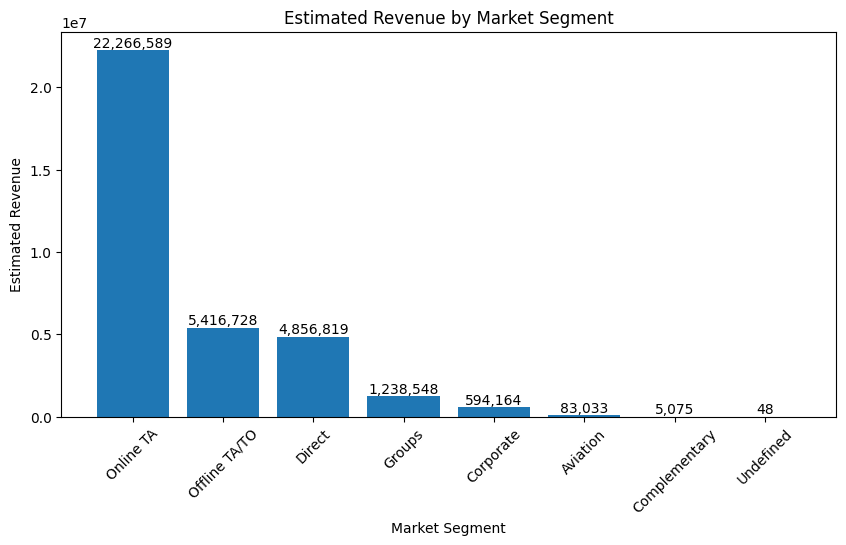

In [156]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    revenue_by_segment.index,
    revenue_by_segment.values
)

plt.title('Estimated Revenue by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Estimated Revenue')

plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom'
    )

plt.show()

In [157]:
df['room_changed'] = (
    df['reserved_room_type'] != df['assigned_room_type']
)

In [158]:
room_change = df['room_changed'].map({
    True: 'Room Changed',
    False: 'Same Room Type'
}).value_counts()

print(room_change)

room_changed
Same Room Type    74287
Room Changed      13109
Name: count, dtype: int64


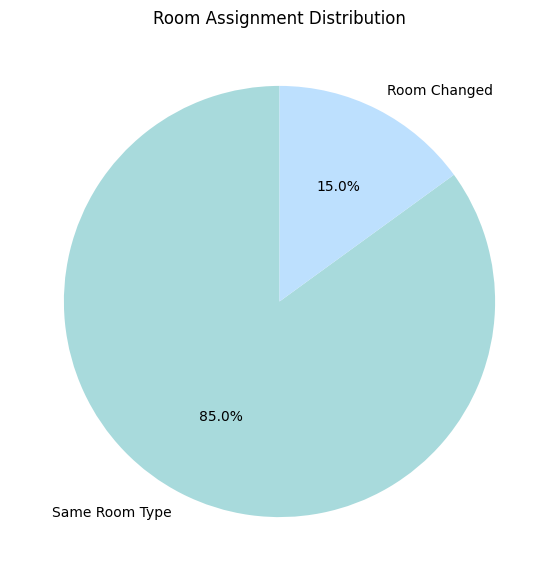

In [161]:
plt.figure(figsize=(7, 7))

plt.pie(
    room_change.values,
    labels=room_change.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#A8DADC', '#BDE0FE']
)

plt.title('Room Assignment Distribution')

plt.show()

In [162]:
df['stay_length_group'] = pd.cut(
    df['total_nights'],
    bins=[0, 2, 4, 7, 14, float('inf')],
    labels=['1-2 nights', '3-4 nights', '5-7 nights', '8-14 nights', '15+ nights'],
    include_lowest=True
)

In [163]:
cancellation_by_stay_length = (
    df.groupby('stay_length_group', observed=True)['is_canceled']
      .mean() * 100
)

print(cancellation_by_stay_length)

stay_length_group
1-2 nights     22.022037
3-4 nights     30.203094
5-7 nights     31.271380
8-14 nights    32.664884
15+ nights     51.069519
Name: is_canceled, dtype: float64


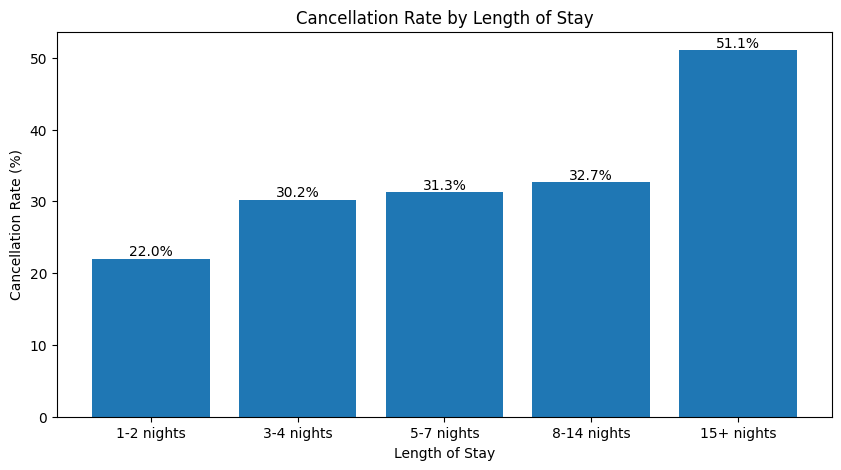

In [164]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    cancellation_by_stay_length.index,
    cancellation_by_stay_length.values
)

plt.title('Cancellation Rate by Length of Stay')
plt.xlabel('Length of Stay')
plt.ylabel('Cancellation Rate (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()